 # <span style="color:darkorange">Analisa Data : New York City TLC Trip Record  </span>
 **Data analyst: Troy Kornelius Daniel**

# <span style="color:darkorange"> BAB 1 PENDAHULUAN </span>

## <span style="color:darkorange">1.1 Latar Belakang</span>

New York City (NYC) adalah salah satu kota terbesar dan paling padat di dunia, dengan sistem transportasi yang kompleks dan beragam. Salah satu komponen penting dari sistem transportasi NYC adalah layanan taksi, yang memainkan peran krusial dalam mobilitas penduduk dan wisatawan. NYC Taxi and Limousine Commission (TLC) mengatur dan mengawasi layanan taksi dan limusin di kota ini, dan mereka menyediakan data yang komprehensif mengenai perjalanan taksi yang dilakukan di NYC.

Dataset NYC TLC Trip Record mencakup informasi rinci tentang setiap perjalanan taksi, termasuk waktu penjemputan, waktu penurunan, jarak perjalanan, jumlah penumpang, dan jumlah tip yang diberikan. Data ini sangat berharga untuk analisis dan penelitian, karena dapat memberikan wawasan tentang pola perjalanan, perilaku penumpang, dan faktor-faktor yang mempengaruhi tarif dan tip.

## <span style="color:darkorange">1.2 Pernyataan Masalah</span>
1. Hubungan Kategori Pick Up dengan Trip Duration : Dengan menganalisis durasi perjalanan berdasarkan kategori penjemputan, kita dapat mengidentifikasi pola yang mungkin ada, seperti apakah perjalanan lebih lama selama jam sibuk dibandingkan dengan waktu lainnya.
2. Hubungan Kategori Pick Up dengan Fare Amount : Memahami hubungan antara kategori penjemputan dan fare amount sangat penting untuk perusahaan taksi dalam merencanakan strategi penetapan harga, meningkatkan kepuasan pelanggan, dan mengoptimalkan pendapatan.
3. Hubungan Katagori Pick Up dengan Tip Amount : Memahami hubungan antara kategori penjemputan dan tip amount sangat penting bagi pengemudi dan perusahaan taksi untuk meningkatkan pengalaman penumpang dan merumuskan strategi yang lebih baik dalam memberikan layanan.


# <span style="color:darkorange">BAB 2 PEMBAHASAN</span>


In [341]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import normaltest, chi2_contingency, mannwhitneyu, ttest_ind
from datetime import datetime
import missingno as msno
import plotly
import plotly.graph_objects as go
from plotly.subplots import make_subplots

import warnings
warnings.filterwarnings("ignore")

In [269]:
df = pd.read_csv('NYC TLC Trip Record.csv')
display(df.head(),df.tail())

,VendorID,lpep_pickup_datetime,lpep_dropoff_datetime,store_and_fwd_flag,RatecodeID,PULocationID,DOLocationID,passenger_count,trip_distance,fare_amount,extra,mta_tax,tip_amount,tolls_amount,ehail_fee,improvement_surcharge,total_amount,payment_type,trip_type,congestion_surcharge
0,2,2023-01-01 00:26:10,2023-01-01 00:37:11,N,1.0,166,143,1.0,2.58,14.9,1.0,0.5,4.03,0.0,NaN,1.0,24.18,1.0,1.0,2.75
1,2,2023-01-01 00:51:03,2023-01-01 00:57:49,N,1.0,24,43,1.0,1.81,10.7,1.0,0.5,2.64,0.0,NaN,1.0,15.84,1.0,1.0,0.00
2,2,2023-01-01 00:35:12,2023-01-01 00:41:32,N,1.0,223,179,1.0,0.00,7.2,1.0,0.5,1.94,0.0,NaN,1.0,11.64,1.0,1.0,0.00
3,1,2023-01-01 00:13:14,2023-01-01 00:19:03,N,1.0,41,238,1.0,1.30,6.5,0.5,1.5,1.70,0.0,NaN,1.0,10.20,1.0,1.0,0.00
4,1,2023-01-01 00:33:04,2023-01-01 00:39:02,N,1.0,41,74,1.0,1.10,6.0,0.5,1.5,0.00,0.0,NaN,1.0,8.00,1.0,1.0,0.00


,VendorID,lpep_pickup_datetime,lpep_dropoff_datetime,store_and_fwd_flag,RatecodeID,PULocationID,DOLocationID,passenger_count,trip_distance,fare_amount,extra,mta_tax,tip_amount,tolls_amount,ehail_fee,improvement_surcharge,total_amount,payment_type,trip_type,congestion_surcharge
68206,2,2023-01-31 22:29:00,2023-01-31 22:42:00,NaN,NaN,49,62,NaN,4070.82,15.70,0.0,0.0,0.00,0.0,NaN,1.0,16.70,NaN,NaN,NaN
68207,2,2023-01-31 22:40:00,2023-01-31 22:48:00,NaN,NaN,10,205,NaN,2.14,4.41,0.0,0.0,0.00,0.0,NaN,1.0,5.41,NaN,NaN,NaN
68208,2,2023-01-31 23:46:00,2023-02-01 00:02:00,NaN,NaN,66,37,NaN,3.44,16.53,0.0,0.0,3.51,0.0,NaN,1.0,21.04,NaN,NaN,NaN
68209,2,2023-01-31 23:01:00,2023-01-31 23:19:00,NaN,NaN,225,189,NaN,3.03,14.98,0.0,0.0,3.20,0.0,NaN,1.0,19.18,NaN,NaN,NaN
68210,2,2023-01-31 23:51:00,2023-02-01 00:07:00,NaN,NaN,256,140,NaN,5.82,23.65,0.0,0.0,2.00,0.0,NaN,1.0,29.40,NaN,NaN,NaN


Deskripsi Kolom dalam NYC TLC Trip Record
* lpep_pickup_datetime:
Deskripsi: Waktu dan tanggal saat penjemputan dilakukan.
Tipe Data: Datetime
* lpep_dropoff_datetime:
Deskripsi: Waktu dan tanggal saat penurunan dilakukan.
Tipe Data: Datetime
* trip_duration:
Deskripsi: Durasi perjalanan, dihitung sebagai selisih antara waktu penjemputan dan waktu penurunan (dalam detik).
Tipe Data: Integer
* pickup_location_id:
Deskripsi: ID lokasi penjemputan, yang menunjukkan area geografis tempat penjemputan terjadi.
Tipe Data: Integer
* dropoff_location_id:
Deskripsi: ID lokasi penurunan, yang menunjukkan area geografis tempat penurunan terjadi.
Tipe Data: Integer
* passenger_count:
Deskripsi: Jumlah penumpang yang diangkut dalam perjalanan.
Tipe Data: Integer
* trip_distance:
Deskripsi: Jarak perjalanan yang ditempuh, biasanya diukur dalam mil.
Tipe Data: Float
* fare_amount:
Deskripsi: Jumlah tarif yang dikenakan untuk perjalanan, sebelum tip dan biaya tambahan.
Tipe Data: Float
* extra:
Deskripsi: Biaya tambahan yang mungkin dikenakan, seperti biaya tol atau biaya tambahan lainnya.
Tipe Data: Float
* mta_tax:
Deskripsi: Pajak yang dikenakan oleh Metropolitan Transportation Authority (MTA) untuk perjalanan taksi.
Tipe Data: Float
* tip_amount:
Deskripsi: Jumlah tip yang diberikan oleh penumpang kepada pengemudi.
Tipe Data: Float
* tolls_amount:
Deskripsi: Jumlah biaya tol yang dibayarkan selama perjalanan.
Tipe Data: Float
* payment_type:
Deskripsi: Metode pembayaran yang digunakan untuk membayar tarif, seperti tunai, kartu kredit, atau aplikasi pembayaran.
Tipe Data: Kategori (categorical)
* vendor_id:
Deskripsi: ID vendor taksi yang menyediakan layanan, biasanya menunjukkan perusahaan taksi tertentu.
Tipe Data: Kategori (categorical)
* time_category:
Deskripsi: Kategori waktu penjemputan, yang dapat mencakup "Rush Hour," "Off Hour," dan "Late Night."
Tipe Data: Kategori (categorical)

# Menambah data tambahan yang berisi penjelasan pada pickup_location_id dan dropoff_location_id

In [270]:
df_zones = pd.read_csv("taxi_zone.csv")
display(df_zones.head(), df_zones.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 265 entries, 0 to 264
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   LocationID    265 non-null    int64 
 1   Borough       265 non-null    object
 2   Zone          264 non-null    object
 3   service_zone  263 non-null    object
dtypes: int64(1), object(3)
memory usage: 8.4+ KB


,LocationID,Borough,Zone,service_zone
0,1,EWR,Newark Airport,EWR
1,2,Queens,Jamaica Bay,Boro Zone
2,3,Bronx,Allerton/Pelham Gardens,Boro Zone
3,4,Manhattan,Alphabet City,Yellow Zone
4,5,Staten Island,Arden Heights,Boro Zone


None

# Menggabungkan kedua CSV

In [271]:
df = pd.DataFrame(df)
df_zone = pd.DataFrame(df_zones)

# Merge untuk Pickup Location
df = pd.merge(
    df,
    df_zone,
    left_on="PULocationID",
    right_on="LocationID",
    how="inner",
    suffixes=("", "_pickup"),
)
df.rename(columns={"Zone": "PUZone", "Borough": "Pickup_Borough"}, inplace=True)
df.drop(columns=["LocationID", "service_zone"], inplace=True)

# Merge untuk Dropoff Location
df = pd.merge(
    df,
    df_zone,
    left_on="DOLocationID",
    right_on="LocationID",
    how="inner",
    suffixes=("", "_dropoff"),
)
df.rename(columns={"Zone": "DOZone", "Borough": "Dropoff_Borough"}, inplace=True)
df.drop(columns=["LocationID", "service_zone"], inplace=True)

# Hasil akhir
display(df)


,VendorID,lpep_pickup_datetime,lpep_dropoff_datetime,store_and_fwd_flag,RatecodeID,PULocationID,DOLocationID,passenger_count,trip_distance,fare_amount,...,ehail_fee,improvement_surcharge,total_amount,payment_type,trip_type,congestion_surcharge,Pickup_Borough,PUZone,Dropoff_Borough,DOZone
0,2,2023-01-01 00:26:10,2023-01-01 00:37:11,N,1.0,166,143,1.0,2.58,14.90,...,NaN,1.0,24.18,1.0,1.0,2.75,Manhattan,Morningside Heights,Manhattan,Lincoln Square West
1,2,2023-01-01 00:51:03,2023-01-01 00:57:49,N,1.0,24,43,1.0,1.81,10.70,...,NaN,1.0,15.84,1.0,1.0,0.00,Manhattan,Bloomingdale,Manhattan,Central Park
2,2,2023-01-01 00:35:12,2023-01-01 00:41:32,N,1.0,223,179,1.0,0.00,7.20,...,NaN,1.0,11.64,1.0,1.0,0.00,Queens,Steinway,Queens,Old Astoria
3,1,2023-01-01 00:13:14,2023-01-01 00:19:03,N,1.0,41,238,1.0,1.30,6.50,...,NaN,1.0,10.20,1.0,1.0,0.00,Manhattan,Central Harlem,Manhattan,Upper West Side North
4,1,2023-01-01 00:33:04,2023-01-01 00:39:02,N,1.0,41,74,1.0,1.10,6.00,...,NaN,1.0,8.00,1.0,1.0,0.00,Manhattan,Central Harlem,Manhattan,East Harlem North
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
68206,2,2023-01-31 22:29:00,2023-01-31 22:42:00,NaN,NaN,49,62,NaN,4070.82,15.70,...,NaN,1.0,16.70,NaN,NaN,NaN,Brooklyn,Clinton Hill,Brooklyn,Crown Heights South
68207,2,2023-01-31 22:40:00,2023-01-31 22:48:00,NaN,NaN,10,205,NaN,2.14,4.41,...,NaN,1.0,5.41,NaN,NaN,NaN,Queens,Baisley Park,Queens,Saint Albans
68208,2,2023-01-31 23:46:00,2023-02-01 00:02:00,NaN,NaN,66,37,NaN,3.44,16.53,...,NaN,1.0,21.04,NaN,NaN,NaN,Brooklyn,DUMBO/Vinegar Hill,Brooklyn,Bushwick South
68209,2,2023-01-31 23:01:00,2023-01-31 23:19:00,NaN,NaN,225,189,NaN,3.03,14.98,...,NaN,1.0,19.18,NaN,NaN,NaN,Brooklyn,Stuyvesant Heights,Brooklyn,Prospect Heights


# Melihat Jumlah Data Kosong

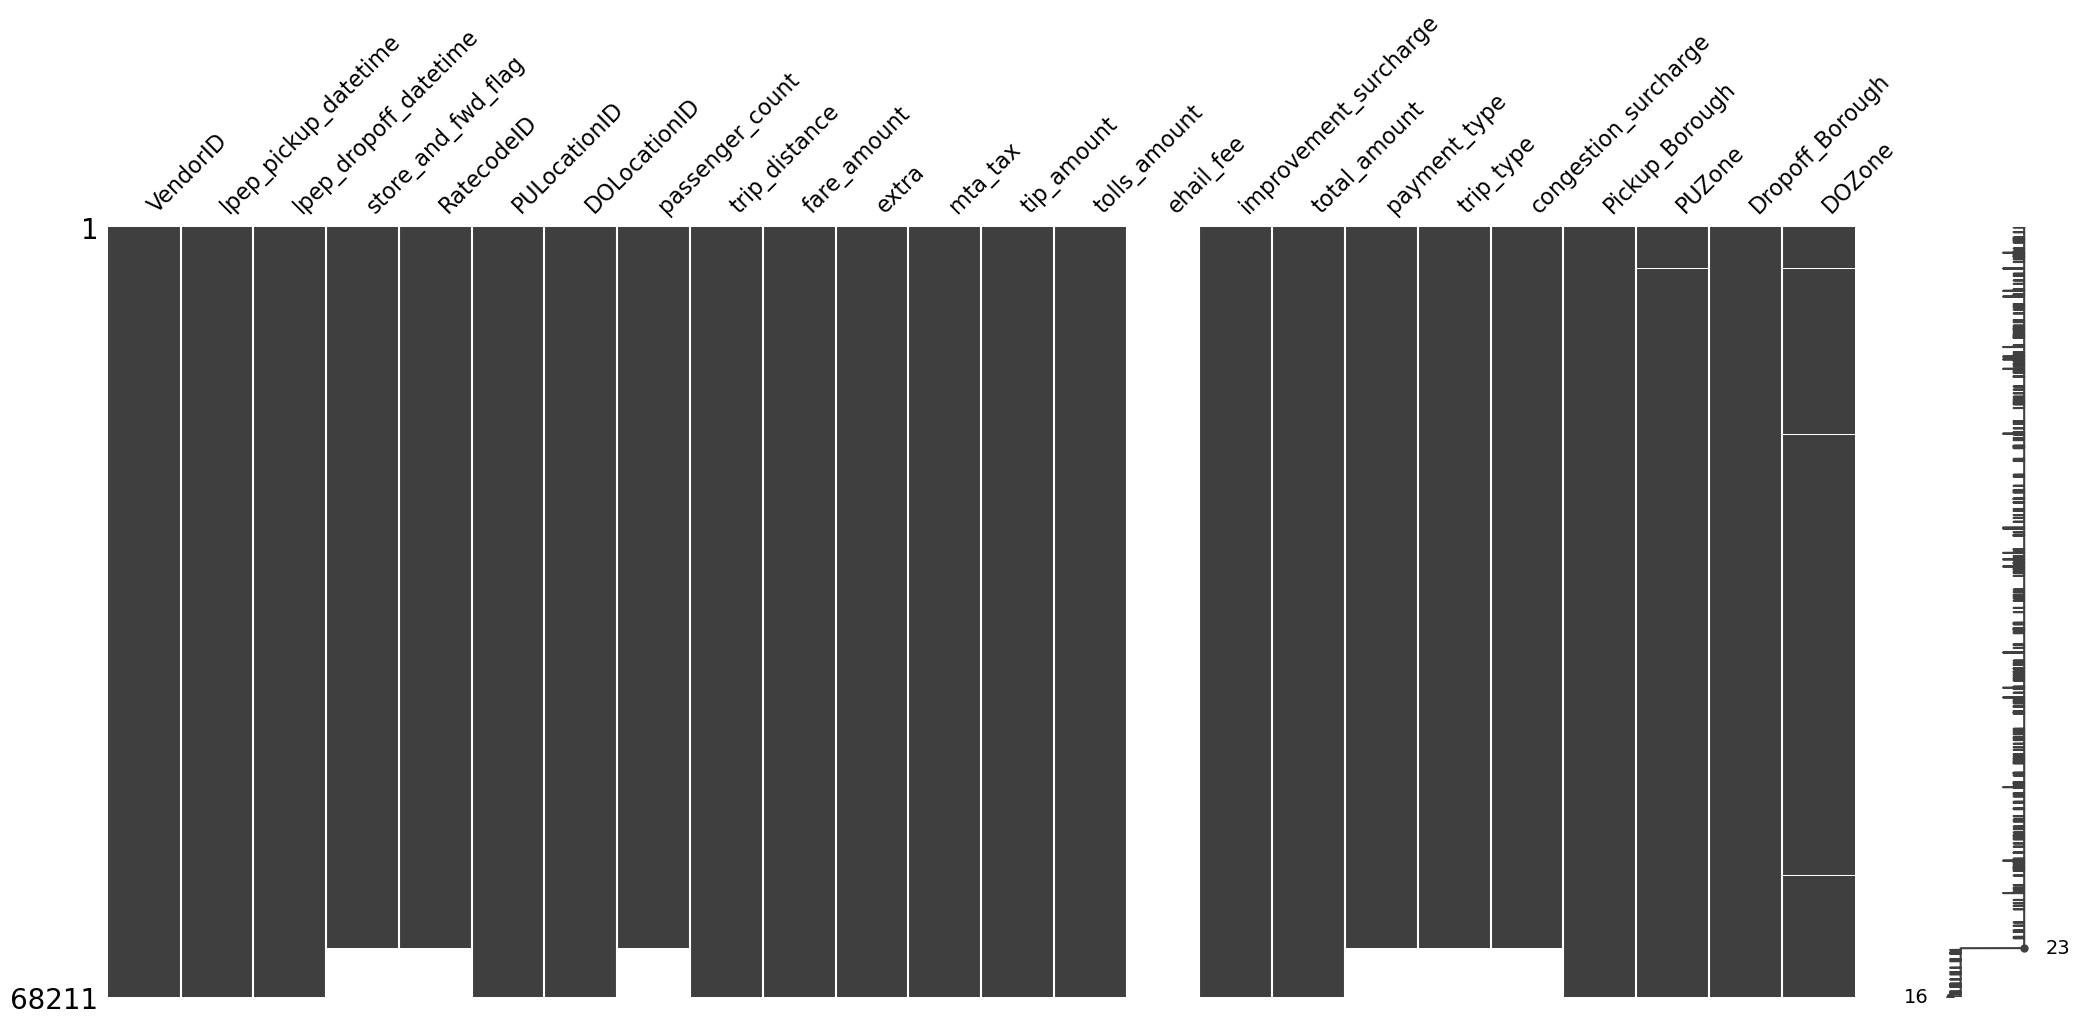

VendorID                   0.000000
lpep_pickup_datetime       0.000000
lpep_dropoff_datetime      0.000000
store_and_fwd_flag         6.339154
RatecodeID                 6.339154
PULocationID               0.000000
DOLocationID               0.000000
passenger_count            6.339154
trip_distance              0.000000
fare_amount                0.000000
extra                      0.000000
mta_tax                    0.000000
tip_amount                 0.000000
tolls_amount               0.000000
ehail_fee                100.000000
improvement_surcharge      0.000000
total_amount               0.000000
payment_type               6.339154
trip_type                  6.353814
congestion_surcharge       6.339154
Pickup_Borough             0.000000
PUZone                     0.096759
Dropoff_Borough            0.000000
DOZone                     0.354781
dtype: float64

In [272]:
#melihat jumlah data NaN
msno.matrix(df)
plt.show()
df.isna().sum()/df.shape[0]*100

Pada fitur ehail_fee, seluruh data berisi data kosong sehingga bisa di drop

In [273]:
#Drop fitur ehail_fee
df.drop("ehail_fee", axis = 1,inplace=True)

Terdapat outlier data pada trip_distance sehingga saya drop data bernilai 0 dan memiliki jarak diatas 100 miles

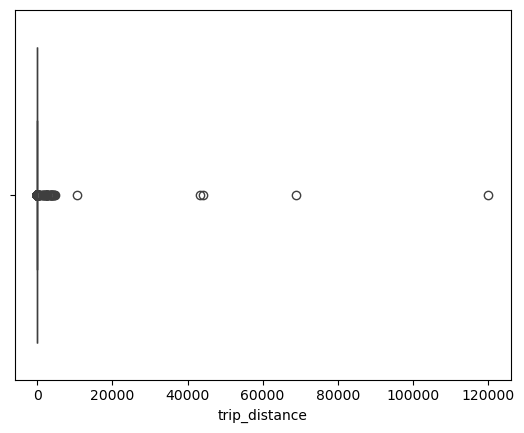

In [274]:
sns.boxplot(data=df, x='trip_distance')
plt.show()

In [275]:
df.drop(df[(df['trip_distance'] >= 100) | (df['trip_distance'] == 0)].index, inplace=True)
df

,VendorID,lpep_pickup_datetime,lpep_dropoff_datetime,store_and_fwd_flag,RatecodeID,PULocationID,DOLocationID,passenger_count,trip_distance,fare_amount,...,tolls_amount,improvement_surcharge,total_amount,payment_type,trip_type,congestion_surcharge,Pickup_Borough,PUZone,Dropoff_Borough,DOZone
0,2,2023-01-01 00:26:10,2023-01-01 00:37:11,N,1.0,166,143,1.0,2.58,14.90,...,0.0,1.0,24.18,1.0,1.0,2.75,Manhattan,Morningside Heights,Manhattan,Lincoln Square West
1,2,2023-01-01 00:51:03,2023-01-01 00:57:49,N,1.0,24,43,1.0,1.81,10.70,...,0.0,1.0,15.84,1.0,1.0,0.00,Manhattan,Bloomingdale,Manhattan,Central Park
3,1,2023-01-01 00:13:14,2023-01-01 00:19:03,N,1.0,41,238,1.0,1.30,6.50,...,0.0,1.0,10.20,1.0,1.0,0.00,Manhattan,Central Harlem,Manhattan,Upper West Side North
4,1,2023-01-01 00:33:04,2023-01-01 00:39:02,N,1.0,41,74,1.0,1.10,6.00,...,0.0,1.0,8.00,1.0,1.0,0.00,Manhattan,Central Harlem,Manhattan,East Harlem North
5,2,2023-01-01 00:53:31,2023-01-01 01:11:04,N,1.0,41,262,1.0,2.78,17.70,...,0.0,1.0,22.95,2.0,1.0,2.75,Manhattan,Central Harlem,Manhattan,Yorkville East
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
68205,2,2023-01-31 21:56:00,2023-01-31 22:14:00,NaN,NaN,75,186,NaN,3.92,20.72,...,0.0,0.3,25.02,NaN,NaN,NaN,Manhattan,East Harlem South,Manhattan,Penn Station/Madison Sq West
68207,2,2023-01-31 22:40:00,2023-01-31 22:48:00,NaN,NaN,10,205,NaN,2.14,4.41,...,0.0,1.0,5.41,NaN,NaN,NaN,Queens,Baisley Park,Queens,Saint Albans
68208,2,2023-01-31 23:46:00,2023-02-01 00:02:00,NaN,NaN,66,37,NaN,3.44,16.53,...,0.0,1.0,21.04,NaN,NaN,NaN,Brooklyn,DUMBO/Vinegar Hill,Brooklyn,Bushwick South
68209,2,2023-01-31 23:01:00,2023-01-31 23:19:00,NaN,NaN,225,189,NaN,3.03,14.98,...,0.0,1.0,19.18,NaN,NaN,NaN,Brooklyn,Stuyvesant Heights,Brooklyn,Prospect Heights


Mengisi data NaN dengan nilai modus karena data kosong hanya terdiri dari 6.3% dari total data sehingga bisa menggunakan metode simple input

In [276]:
df['trip_type'].fillna(df['trip_type'].mode()[0], inplace=True)

In [282]:
df['congestion_surcharge'].fillna(df['congestion_surcharge'].mode()[0], inplace=True)

In [283]:
df.drop(df[df['RatecodeID'] == 99.0].index, inplace=True)

In [284]:
df['store_and_fwd_flag'].fillna(df['store_and_fwd_flag'].mode()[0], inplace=True)

In [285]:
df['RatecodeID'].fillna(df['RatecodeID'].mode()[0], inplace=True)

In [286]:
df['passenger_count'].fillna(df['passenger_count'].mode()[0], inplace=True)

In [287]:
df['payment_type'].fillna(df['payment_type'].mode()[0], inplace=True)

In [288]:
df = df.dropna(subset=['PUZone','DOZone']).reset_index(drop=True)

In [289]:
# Fill missing values in specific columns with "Unknown"
columns_to_fill = ['Pickup_Borough', 'Dropoff_Borough']
df[columns_to_fill] = df[columns_to_fill].fillna("Unknown")

Mengubah Tipe Data

In [290]:
# Konversi kolom menjadi tipe 'category'
category_cols = [
    "VendorID", "store_and_fwd_flag", "PULocationID", "DOLocationID", 
    "RatecodeID", "payment_type", "trip_type"
]
df[category_cols] = df[category_cols].astype("category")

# Konversi tipe 'int' sebelum 'category' untuk beberapa kolom
int_to_category_cols = ["RatecodeID", "payment_type", "trip_type"]
df[int_to_category_cols] = df[int_to_category_cols].astype("int").astype("category")

# Konversi tipe 'int' untuk kolom lainnya
df["passenger_count"] = df["passenger_count"].astype("int")

# Konversi tipe datetime
datetime_cols = ["lpep_pickup_datetime", "lpep_dropoff_datetime"]
df[datetime_cols] = df[datetime_cols].apply(pd.to_datetime)

display(df.head(),df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 64599 entries, 0 to 64598
Data columns (total 23 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   VendorID               64599 non-null  category      
 1   lpep_pickup_datetime   64599 non-null  datetime64[ns]
 2   lpep_dropoff_datetime  64599 non-null  datetime64[ns]
 3   store_and_fwd_flag     64599 non-null  category      
 4   RatecodeID             64599 non-null  category      
 5   PULocationID           64599 non-null  category      
 6   DOLocationID           64599 non-null  category      
 7   passenger_count        64599 non-null  int32         
 8   trip_distance          64599 non-null  float64       
 9   fare_amount            64599 non-null  float64       
 10  extra                  64599 non-null  float64       
 11  mta_tax                64599 non-null  float64       
 12  tip_amount             64599 non-null  float64       
 13  t

,VendorID,lpep_pickup_datetime,lpep_dropoff_datetime,store_and_fwd_flag,RatecodeID,PULocationID,DOLocationID,passenger_count,trip_distance,fare_amount,...,tolls_amount,improvement_surcharge,total_amount,payment_type,trip_type,congestion_surcharge,Pickup_Borough,PUZone,Dropoff_Borough,DOZone
0,2,2023-01-01 00:26:10,2023-01-01 00:37:11,N,1,166,143,1,2.58,14.9,...,0.0,1.0,24.18,1,1,2.75,Manhattan,Morningside Heights,Manhattan,Lincoln Square West
1,2,2023-01-01 00:51:03,2023-01-01 00:57:49,N,1,24,43,1,1.81,10.7,...,0.0,1.0,15.84,1,1,0.00,Manhattan,Bloomingdale,Manhattan,Central Park
2,1,2023-01-01 00:13:14,2023-01-01 00:19:03,N,1,41,238,1,1.30,6.5,...,0.0,1.0,10.20,1,1,0.00,Manhattan,Central Harlem,Manhattan,Upper West Side North
3,1,2023-01-01 00:33:04,2023-01-01 00:39:02,N,1,41,74,1,1.10,6.0,...,0.0,1.0,8.00,1,1,0.00,Manhattan,Central Harlem,Manhattan,East Harlem North
4,2,2023-01-01 00:53:31,2023-01-01 01:11:04,N,1,41,262,1,2.78,17.7,...,0.0,1.0,22.95,2,1,2.75,Manhattan,Central Harlem,Manhattan,Yorkville East


None

In [291]:
df.duplicated().sum()

0

In [292]:
df.isna().sum()

VendorID                 0
lpep_pickup_datetime     0
lpep_dropoff_datetime    0
store_and_fwd_flag       0
RatecodeID               0
PULocationID             0
DOLocationID             0
passenger_count          0
trip_distance            0
fare_amount              0
extra                    0
mta_tax                  0
tip_amount               0
tolls_amount             0
improvement_surcharge    0
total_amount             0
payment_type             0
trip_type                0
congestion_surcharge     0
Pickup_Borough           0
PUZone                   0
Dropoff_Borough          0
DOZone                   0
dtype: int64

In [293]:
df.describe()

,lpep_pickup_datetime,lpep_dropoff_datetime,passenger_count,trip_distance,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge
count,64599,64599,64599.000000,64599.000000,64599.000000,64599.000000,64599.000000,64599.000000,64599.000000,64599.000000,64599.000000,64599.000000
mean,2023-01-16 20:36:24.430920192,2023-01-16 20:54:23.775538432,1.304834,2.767434,16.246365,0.855439,0.577896,2.188717,0.149046,0.954323,21.524557,0.711969
min,2009-01-01 20:21:27,2009-01-02 11:07:31,0.000000,0.010000,-70.000000,-2.500000,-0.500000,0.000000,0.000000,-1.000000,-71.500000,-2.750000
25%,2023-01-09 12:23:18.500000,2023-01-09 12:39:33,1.000000,1.220000,9.300000,0.000000,0.500000,0.000000,0.000000,1.000000,12.950000,0.000000
50%,2023-01-17 09:12:00,2023-01-17 09:26:58,1.000000,1.930000,12.800000,0.000000,0.500000,1.800000,0.000000,1.000000,17.810000,0.000000
75%,2023-01-24 16:05:58,2023-01-24 16:21:51,1.000000,3.300000,19.100000,1.000000,0.500000,3.400000,0.000000,1.000000,25.980000,2.750000
max,2023-02-01 03:10:05,2023-02-01 17:27:05,8.000000,66.180000,455.000000,12.500000,1.500000,222.220000,36.050000,1.000000,456.000000,2.750000
std,NaN,NaN,0.963876,2.660386,11.762473,1.283419,0.364012,2.978919,1.003409,0.185236,13.950999,1.204818


Karena terdapat data Negatif, saya menganggapnya sebagai salah input dan membuat datanya menjadi Absolute untuk mengubah nilai negatif menjadi positif

In [296]:
fare_related_columns = [
    'fare_amount', 
    'extra', 
    'mta_tax', 
    'tip_amount', 
    'improvement_surcharge', 
    'total_amount', 
    'tolls_amount', 
    'congestion_surcharge'
]

df[fare_related_columns] = df[fare_related_columns].applymap(abs)

In [297]:
df[df['passenger_count']==0]

,VendorID,lpep_pickup_datetime,lpep_dropoff_datetime,store_and_fwd_flag,RatecodeID,PULocationID,DOLocationID,passenger_count,trip_distance,fare_amount,...,tolls_amount,improvement_surcharge,total_amount,payment_type,trip_type,congestion_surcharge,Pickup_Borough,PUZone,Dropoff_Borough,DOZone
234,1,2023-01-01 04:21:35,2023-01-01 04:30:00,N,1,129,129,0,1.3,8.0,...,4.0,1.0,16.80,1,1,0.00,Queens,Jackson Heights,Queens,Jackson Heights
414,1,2023-01-01 11:42:13,2023-01-01 11:49:21,N,1,260,260,0,1.2,8.6,...,0.0,1.0,12.10,1,1,0.00,Queens,Woodside,Queens,Woodside
452,1,2023-01-01 12:11:05,2023-01-01 12:20:45,N,1,42,127,0,3.4,16.3,...,0.0,1.0,18.80,1,1,0.00,Manhattan,Central Harlem North,Manhattan,Inwood
453,1,2023-01-01 12:56:11,2023-01-01 13:01:06,N,1,75,236,0,1.2,7.2,...,0.0,1.0,14.85,1,1,2.75,Manhattan,East Harlem South,Manhattan,Upper East Side North
586,1,2023-01-01 14:10:14,2023-01-01 14:22:27,N,1,260,223,0,2.9,14.9,...,0.0,1.0,19.65,1,1,0.00,Queens,Woodside,Queens,Steinway
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
59534,1,2023-01-31 16:41:24,2023-01-31 17:00:06,N,1,75,74,0,1.3,17.0,...,0.0,1.0,25.20,1,1,0.00,Manhattan,East Harlem South,Manhattan,East Harlem North
59700,1,2023-01-31 17:31:16,2023-01-31 17:35:58,N,1,75,236,0,0.9,7.2,...,0.0,1.0,17.40,1,1,2.75,Manhattan,East Harlem South,Manhattan,Upper East Side North
59701,1,2023-01-31 17:45:26,2023-01-31 17:53:17,N,1,75,263,0,1.2,9.3,...,0.0,1.0,19.25,1,1,2.75,Manhattan,East Harlem South,Manhattan,Yorkville West
59860,1,2023-01-31 18:01:21,2023-01-31 18:09:22,N,1,236,236,0,1.0,9.3,...,0.0,1.0,19.25,1,1,2.75,Manhattan,Upper East Side North,Manhattan,Upper East Side North


In [298]:
df.loc[df['passenger_count'] == 0, 'passenger_count'] = df.loc[df['passenger_count'] != 0, 'passenger_count'].mode()[0]

Disini saya melakukan drop pada data fare_amount yang dibawah 0.3$, hal ini saya lakukan karena ketentuan dari NYC Taxi itu sendiri menyatakan
bahwa minimum fare amount adalah 0.3$ dan menganggap seluruh data yang memiliki fare_amount dibawah 0.3$ adalah outlier.

In [299]:
df.drop(df[df['fare_amount'] < 0.3].index, inplace=True)

Seharusnya data saya hanya berisi data NYC TAXI pada periode 1 Januari 2023 - 31 Januari 2023, maka saya melakukan drop data yang berada di luar rentang tanggal tersebut

In [300]:
# Menghapus data yang tahunnya 2009 dan 2022
df = df[~df['lpep_pickup_datetime'].dt.year.isin([2009, 2022])].reset_index(drop=True)
df = df[~df['lpep_dropoff_datetime'].dt.year.isin([2009, 2022])].reset_index(drop=True)

In [301]:
df.loc[df['mta_tax'] != 0.5, 'mta_tax'] = 0.5

In [302]:
df.loc[df['improvement_surcharge'] != 1.0, 'improvement_surcharge'] = 1.0

Menambahkan kolom calculated total karena pada kolom Fare_amount, total harga belum termasuk biaya-biaya tambahan lainnya

In [304]:
# Calculate the expected total amount
df['calculated_total'] = (df['fare_amount'] + 
                          df['extra'] + 
                          df['mta_tax'] + 
                          df['tip_amount'] + 
                          df['improvement_surcharge'] + 
                          df['tolls_amount'] + 
                          df['congestion_surcharge'])

# Add a column to indicate whether the total matches
df['total_matches'] = df['calculated_total'] == df['total_amount']

# Filter rows where the total does not match
mismatched_rows = df[~df['total_matches']]

# Check the proportion of mismatched rows
mismatched_proportion = (len(mismatched_rows) / len(df)) * 100
print(f"Proportion of mismatched rows: {mismatched_proportion:.2f}%")

Proportion of mismatched rows: 24.28%


In [305]:
# Impute the correct total into mismatched rows
df.loc[~df['total_matches'], 'total_amount'] = df.loc[~df['total_matches'], 'calculated_total']

# Drop unnecessary columns
df = df.drop(columns=['total_matches'])

In [306]:
df.duplicated().sum()

102

In [307]:
# Drop duplicate rows and keep the first occurrence
df = df.drop_duplicates()

In [308]:
df.duplicated().sum()

0

In [309]:
df.describe()

,lpep_pickup_datetime,lpep_dropoff_datetime,passenger_count,trip_distance,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,calculated_total
count,64471,64471,64471.000000,64471.000000,64471.000000,64471.000000,64471.0,64471.000000,64471.000000,64471.0,64471.000000,64471.000000,64471.000000
mean,2023-01-16 22:34:58.035566336,2023-01-16 22:52:56.786353664,1.309100,2.769174,16.290842,0.858487,0.5,2.192265,0.149139,1.0,21.704116,0.713383,21.704116
min,2023-01-01 00:01:31,2023-01-01 00:13:26,1.000000,0.010000,0.300000,0.000000,0.5,0.000000,0.000000,1.0,1.800000,0.000000,1.800000
25%,2023-01-09 12:28:00,2023-01-09 12:40:57,1.000000,1.220000,9.300000,0.000000,0.5,0.000000,0.000000,1.0,12.960000,0.000000,12.960000
50%,2023-01-17 09:15:20,2023-01-17 09:32:00,1.000000,1.930000,12.890000,0.000000,0.5,1.820000,0.000000,1.0,18.000000,0.000000,18.000000
75%,2023-01-24 16:06:28,2023-01-24 16:22:25,1.000000,3.300000,19.100000,1.000000,0.5,3.410000,0.000000,1.0,26.180000,2.750000,26.180000
max,2023-02-01 03:10:05,2023-02-01 17:27:05,8.000000,66.180000,455.000000,12.500000,0.5,222.220000,36.050000,1.0,456.500000,2.750000,456.500000
std,NaN,NaN,0.960183,2.648616,11.727940,1.282108,0.0,2.978938,1.003750,0.0,13.907023,1.205303,13.907023


In [310]:
df

,VendorID,lpep_pickup_datetime,lpep_dropoff_datetime,store_and_fwd_flag,RatecodeID,PULocationID,DOLocationID,passenger_count,trip_distance,fare_amount,...,improvement_surcharge,total_amount,payment_type,trip_type,congestion_surcharge,Pickup_Borough,PUZone,Dropoff_Borough,DOZone,calculated_total
0,2,2023-01-01 00:26:10,2023-01-01 00:37:11,N,1,166,143,1,2.58,14.90,...,1.0,24.18,1,1,2.75,Manhattan,Morningside Heights,Manhattan,Lincoln Square West,24.18
1,2,2023-01-01 00:51:03,2023-01-01 00:57:49,N,1,24,43,1,1.81,10.70,...,1.0,15.84,1,1,0.00,Manhattan,Bloomingdale,Manhattan,Central Park,15.84
2,1,2023-01-01 00:13:14,2023-01-01 00:19:03,N,1,41,238,1,1.30,6.50,...,1.0,10.20,1,1,0.00,Manhattan,Central Harlem,Manhattan,Upper West Side North,10.20
3,1,2023-01-01 00:33:04,2023-01-01 00:39:02,N,1,41,74,1,1.10,6.00,...,1.0,8.00,1,1,0.00,Manhattan,Central Harlem,Manhattan,East Harlem North,8.00
4,2,2023-01-01 00:53:31,2023-01-01 01:11:04,N,1,41,262,1,2.78,17.70,...,1.0,22.95,2,1,2.75,Manhattan,Central Harlem,Manhattan,Yorkville East,22.95
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
64568,2,2023-01-31 21:56:00,2023-01-31 22:14:00,N,1,75,186,1,3.92,20.72,...,1.0,23.47,1,1,0.00,Manhattan,East Harlem South,Manhattan,Penn Station/Madison Sq West,23.47
64569,2,2023-01-31 22:40:00,2023-01-31 22:48:00,N,1,10,205,1,2.14,4.41,...,1.0,5.91,1,1,0.00,Queens,Baisley Park,Queens,Saint Albans,5.91
64570,2,2023-01-31 23:46:00,2023-02-01 00:02:00,N,1,66,37,1,3.44,16.53,...,1.0,21.54,1,1,0.00,Brooklyn,DUMBO/Vinegar Hill,Brooklyn,Bushwick South,21.54
64571,2,2023-01-31 23:01:00,2023-01-31 23:19:00,N,1,225,189,1,3.03,14.98,...,1.0,19.68,1,1,0.00,Brooklyn,Stuyvesant Heights,Brooklyn,Prospect Heights,19.68


In [311]:
df[(df["Pickup_Borough"]!="Unknown")&(df["Dropoff_Borough"]!="Unknown")]
df.describe()

,lpep_pickup_datetime,lpep_dropoff_datetime,passenger_count,trip_distance,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,calculated_total
count,64471,64471,64471.000000,64471.000000,64471.000000,64471.000000,64471.0,64471.000000,64471.000000,64471.0,64471.000000,64471.000000,64471.000000
mean,2023-01-16 22:34:58.035566336,2023-01-16 22:52:56.786353664,1.309100,2.769174,16.290842,0.858487,0.5,2.192265,0.149139,1.0,21.704116,0.713383,21.704116
min,2023-01-01 00:01:31,2023-01-01 00:13:26,1.000000,0.010000,0.300000,0.000000,0.5,0.000000,0.000000,1.0,1.800000,0.000000,1.800000
25%,2023-01-09 12:28:00,2023-01-09 12:40:57,1.000000,1.220000,9.300000,0.000000,0.5,0.000000,0.000000,1.0,12.960000,0.000000,12.960000
50%,2023-01-17 09:15:20,2023-01-17 09:32:00,1.000000,1.930000,12.890000,0.000000,0.5,1.820000,0.000000,1.0,18.000000,0.000000,18.000000
75%,2023-01-24 16:06:28,2023-01-24 16:22:25,1.000000,3.300000,19.100000,1.000000,0.5,3.410000,0.000000,1.0,26.180000,2.750000,26.180000
max,2023-02-01 03:10:05,2023-02-01 17:27:05,8.000000,66.180000,455.000000,12.500000,0.5,222.220000,36.050000,1.0,456.500000,2.750000,456.500000
std,NaN,NaN,0.960183,2.648616,11.727940,1.282108,0.0,2.978938,1.003750,0.0,13.907023,1.205303,13.907023


In [261]:
df

,VendorID,lpep_pickup_datetime,lpep_dropoff_datetime,store_and_fwd_flag,RatecodeID,PULocationID,DOLocationID,passenger_count,trip_distance,fare_amount,...,improvement_surcharge,total_amount,payment_type,trip_type,congestion_surcharge,Pickup_Borough,PUZone,Dropoff_Borough,DOZone,calculated_total
0,2,2023-01-01 00:26:10,2023-01-01 00:37:11,N,1,166,143,1,2.58,14.90,...,1.0,24.18,1,1,2.75,Manhattan,Morningside Heights,Manhattan,Lincoln Square West,24.18
1,2,2023-01-01 00:51:03,2023-01-01 00:57:49,N,1,24,43,1,1.81,10.70,...,1.0,15.84,1,1,0.00,Manhattan,Bloomingdale,Manhattan,Central Park,15.84
2,1,2023-01-01 00:13:14,2023-01-01 00:19:03,N,1,41,238,1,1.30,6.50,...,1.0,10.20,1,1,0.00,Manhattan,Central Harlem,Manhattan,Upper West Side North,10.20
3,1,2023-01-01 00:33:04,2023-01-01 00:39:02,N,1,41,74,1,1.10,6.00,...,1.0,8.00,1,1,0.00,Manhattan,Central Harlem,Manhattan,East Harlem North,8.00
4,2,2023-01-01 00:53:31,2023-01-01 01:11:04,N,1,41,262,1,2.78,17.70,...,1.0,22.95,2,1,2.75,Manhattan,Central Harlem,Manhattan,Yorkville East,22.95
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
64568,2,2023-01-31 21:56:00,2023-01-31 22:14:00,N,1,75,186,1,3.92,20.72,...,1.0,23.47,1,1,0.00,Manhattan,East Harlem South,Manhattan,Penn Station/Madison Sq West,23.47
64569,2,2023-01-31 22:40:00,2023-01-31 22:48:00,N,1,10,205,1,2.14,4.41,...,1.0,5.91,1,1,0.00,Queens,Baisley Park,Queens,Saint Albans,5.91
64570,2,2023-01-31 23:46:00,2023-02-01 00:02:00,N,1,66,37,1,3.44,16.53,...,1.0,21.54,1,1,0.00,Brooklyn,DUMBO/Vinegar Hill,Brooklyn,Bushwick South,21.54
64571,2,2023-01-31 23:01:00,2023-01-31 23:19:00,N,1,225,189,1,3.03,14.98,...,1.0,19.68,1,1,0.00,Brooklyn,Stuyvesant Heights,Brooklyn,Prospect Heights,19.68


In [315]:
numerical_columns = df.select_dtypes(include=['number']).columns
print("Kolom numerik:", numerical_columns.tolist())

Kolom numerik: ['passenger_count', 'trip_distance', 'fare_amount', 'extra', 'mta_tax', 'tip_amount', 'tolls_amount', 'improvement_surcharge', 'total_amount', 'congestion_surcharge', 'calculated_total']


In [314]:
for kolom in df_num.columns:  
    stat, p = stats.shapiro(df_num[kolom])  
    print(f'{kolom}: Statistics={stat}, p-value={p}')  
    if p > 0.05:  
        print(f'{kolom} mungkin terdistribusi normal (gagal menolak hipotesis nol)')  
    else:  
        print(f'{kolom} tidak terdistribusi normal (menolak hipotesis nol)')  

passenger_count: Statistics=0.3613990972976905, p-value=1.1765689369208946e-156
passenger_count tidak terdistribusi normal (menolak hipotesis nol)
trip_distance: Statistics=0.7106065325185371, p-value=3.594411559099391e-132
trip_distance tidak terdistribusi normal (menolak hipotesis nol)
fare_amount: Statistics=0.7079716252312689, p-value=1.9371561707460878e-132
fare_amount tidak terdistribusi normal (menolak hipotesis nol)
extra: Statistics=0.6890940765134692, p-value=2.65622378180502e-134
extra tidak terdistribusi normal (menolak hipotesis nol)
mta_tax: Statistics=1.0, p-value=1.0
mta_tax mungkin terdistribusi normal (gagal menolak hipotesis nol)
tip_amount: Statistics=0.6590009096670508, p-value=4.492749401285627e-137
tip_amount tidak terdistribusi normal (menolak hipotesis nol)
tolls_amount: Statistics=0.12865462275849882, p-value=7.605788748347902e-167
tolls_amount tidak terdistribusi normal (menolak hipotesis nol)
improvement_surcharge: Statistics=1.0, p-value=1.0
improvement_sur

## <span style="color:darkorange">ANALISIS DATA</span>

## EXPLORATORY DATA ANALYSYS

Menambah kolom Trip Duration dan mengubah satuannya menjadi menit

In [317]:
df['trip_duration'] = (df['lpep_dropoff_datetime'] - df['lpep_pickup_datetime']).dt.total_seconds() / 60

Menghapus data yang memiliki nilai trip_duration dibawah 0

In [318]:
df = df[df['trip_duration'] > 0]

In [122]:
print(df['trip_duration'].describe())

count    64467.000000
mean        17.980295
std         75.056768
min          0.016667
25%          7.383333
50%         11.416667
75%         17.233333
max       1438.933333
Name: trip_duration, dtype: float64


In [123]:
df

,VendorID,lpep_pickup_datetime,lpep_dropoff_datetime,store_and_fwd_flag,RatecodeID,PULocationID,DOLocationID,passenger_count,trip_distance,fare_amount,...,total_amount,payment_type,trip_type,congestion_surcharge,Pickup_Borough,PUZone,Dropoff_Borough,DOZone,calculated_total,trip_duration
0,2,2023-01-01 00:26:10,2023-01-01 00:37:11,N,1,166,143,1,2.58,14.90,...,24.18,1,1,2.75,Manhattan,Morningside Heights,Manhattan,Lincoln Square West,24.18,11.016667
1,2,2023-01-01 00:51:03,2023-01-01 00:57:49,N,1,24,43,1,1.81,10.70,...,15.84,1,1,0.00,Manhattan,Bloomingdale,Manhattan,Central Park,15.84,6.766667
2,1,2023-01-01 00:13:14,2023-01-01 00:19:03,N,1,41,238,1,1.30,6.50,...,10.20,1,1,0.00,Manhattan,Central Harlem,Manhattan,Upper West Side North,10.20,5.816667
3,1,2023-01-01 00:33:04,2023-01-01 00:39:02,N,1,41,74,1,1.10,6.00,...,8.00,1,1,0.00,Manhattan,Central Harlem,Manhattan,East Harlem North,8.00,5.966667
4,2,2023-01-01 00:53:31,2023-01-01 01:11:04,N,1,41,262,1,2.78,17.70,...,22.95,2,1,2.75,Manhattan,Central Harlem,Manhattan,Yorkville East,22.95,17.550000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
64568,2,2023-01-31 21:56:00,2023-01-31 22:14:00,N,1,75,186,1,3.92,20.72,...,23.47,1,1,0.00,Manhattan,East Harlem South,Manhattan,Penn Station/Madison Sq West,23.47,18.000000
64569,2,2023-01-31 22:40:00,2023-01-31 22:48:00,N,1,10,205,1,2.14,4.41,...,5.91,1,1,0.00,Queens,Baisley Park,Queens,Saint Albans,5.91,8.000000
64570,2,2023-01-31 23:46:00,2023-02-01 00:02:00,N,1,66,37,1,3.44,16.53,...,21.54,1,1,0.00,Brooklyn,DUMBO/Vinegar Hill,Brooklyn,Bushwick South,21.54,16.000000
64571,2,2023-01-31 23:01:00,2023-01-31 23:19:00,N,1,225,189,1,3.03,14.98,...,19.68,1,1,0.00,Brooklyn,Stuyvesant Heights,Brooklyn,Prospect Heights,19.68,18.000000


In [323]:
df['pickup_hour'] = df['lpep_pickup_datetime'].dt.hour

Berdasarkan https://www.nytimes.com/2025/01/05/nyregion/congestion-pricing-uber-lyft.html# , rata-rata Taxi di NYC melakukan total 12x trip dalam 1 hari, maka saya melakukan drop data yang memiliki nilai trip_duration dibawah 40 menit.

In [329]:
df_below_40_mnt = df[df['trip_duration'] <= 40]  
df_below_40_mnt


,VendorID,lpep_pickup_datetime,lpep_dropoff_datetime,store_and_fwd_flag,RatecodeID,PULocationID,DOLocationID,passenger_count,trip_distance,fare_amount,...,trip_type,congestion_surcharge,Pickup_Borough,PUZone,Dropoff_Borough,DOZone,calculated_total,trip_duration,pickup_hour,time_category
0,2,2023-01-01 00:26:10,2023-01-01 00:37:11,N,1,166,143,1,2.58,14.90,...,1,2.75,Manhattan,Morningside Heights,Manhattan,Lincoln Square West,24.18,11.016667,0,Late Night
1,2,2023-01-01 00:51:03,2023-01-01 00:57:49,N,1,24,43,1,1.81,10.70,...,1,0.00,Manhattan,Bloomingdale,Manhattan,Central Park,15.84,6.766667,0,Late Night
2,1,2023-01-01 00:13:14,2023-01-01 00:19:03,N,1,41,238,1,1.30,6.50,...,1,0.00,Manhattan,Central Harlem,Manhattan,Upper West Side North,10.20,5.816667,0,Late Night
3,1,2023-01-01 00:33:04,2023-01-01 00:39:02,N,1,41,74,1,1.10,6.00,...,1,0.00,Manhattan,Central Harlem,Manhattan,East Harlem North,8.00,5.966667,0,Late Night
4,2,2023-01-01 00:53:31,2023-01-01 01:11:04,N,1,41,262,1,2.78,17.70,...,1,2.75,Manhattan,Central Harlem,Manhattan,Yorkville East,22.95,17.550000,0,Late Night
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
64568,2,2023-01-31 21:56:00,2023-01-31 22:14:00,N,1,75,186,1,3.92,20.72,...,1,0.00,Manhattan,East Harlem South,Manhattan,Penn Station/Madison Sq West,23.47,18.000000,21,Off-Peak
64569,2,2023-01-31 22:40:00,2023-01-31 22:48:00,N,1,10,205,1,2.14,4.41,...,1,0.00,Queens,Baisley Park,Queens,Saint Albans,5.91,8.000000,22,Late Night
64570,2,2023-01-31 23:46:00,2023-02-01 00:02:00,N,1,66,37,1,3.44,16.53,...,1,0.00,Brooklyn,DUMBO/Vinegar Hill,Brooklyn,Bushwick South,21.54,16.000000,23,Late Night
64571,2,2023-01-31 23:01:00,2023-01-31 23:19:00,N,1,225,189,1,3.03,14.98,...,1,0.00,Brooklyn,Stuyvesant Heights,Brooklyn,Prospect Heights,19.68,18.000000,23,Late Night


menambah kolom time_category dimana saya mengelompokkan pick-up time.

* Pick-up diantara pukul 07:00 sampai 09:00, dan 16:00 sampai 19:00 saya definisikan sebagai Rush Hour, karena merupakan jam masuk dan pulang kantor

* Pick-up diantara pukul 22:00 sampai 05:00 saya definisikan sebagai Late Night karena waktu Pick-up berada di tengah malam

* Pick-up diluar jam yang saya sebutkan tadi saya definisikan sebagai Off-Peak, karena berada di luar jam masuk dan pulang kantor, serta tidak pada tengah malam

In [331]:
def categorize_time(hour):
    if 7 <= hour <= 9 or 16 <= hour <= 19:
        return 'Rush Hour'
    elif 22 <= hour <= 23 or 0 <= hour <= 5:
        return 'Late Night'
    else:
        return 'Off-Peak'

df_below_40_mnt['time_category'] = df_below_40_mnt['pickup_hour'].apply(categorize_time)

melakukan drop data pada kolom fare_amount diatas 150$

In [343]:
df_below_40_mnt.drop(df_below_40_mnt[df_below_40_mnt['fare_amount'] >150].index, inplace=True)

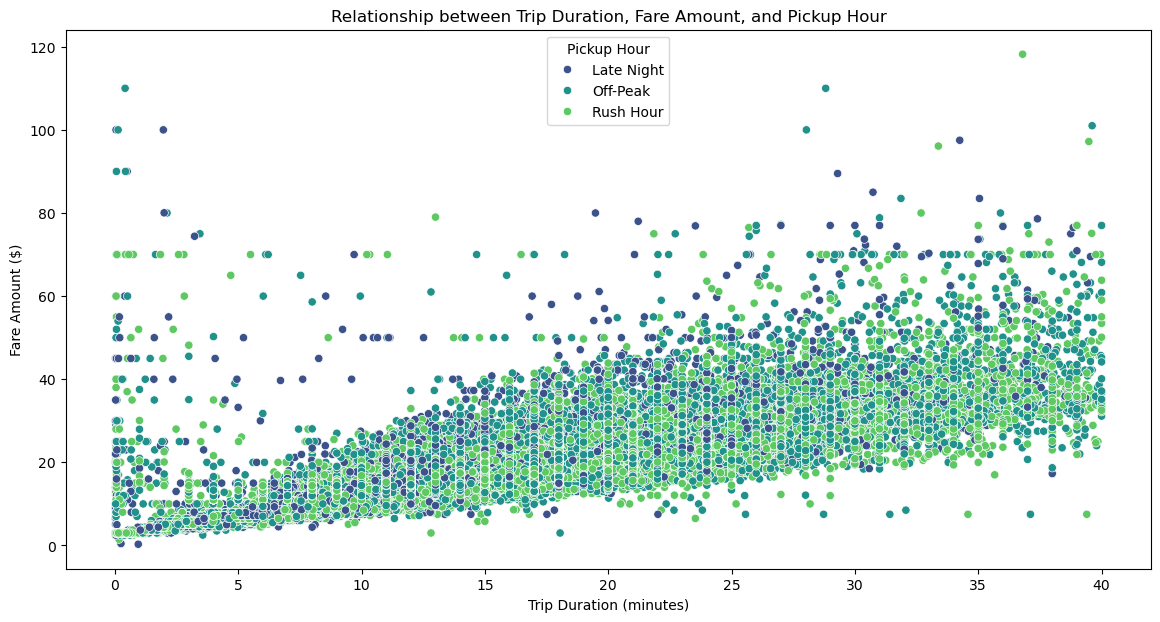

In [344]:
plt.figure(figsize=(14, 7))
sns.scatterplot(data=df_below_40_mnt, x='trip_duration', y='fare_amount', hue='time_category', palette='viridis')
plt.title('Relationship between Trip Duration, Fare Amount, and Pickup Hour')
plt.xlabel('Trip Duration (minutes)')
plt.ylabel('Fare Amount ($)')
plt.legend(title='Pickup Hour')
plt.show()

In [338]:
correlation = df_below_40_mnt['fare_amount'].corr(df_below_40_mnt['trip_duration'])  
  
# Display the correlation value  
print(f'Korelasi antara Fare Amount dan Trip Duration: {correlation}')  

Korelasi antara Fare Amount dan Trip Duration: 0.8326714856013243


Kekuatan Korelasi: Nilai korelasi 0.8327 menunjukkan adanya hubungan yang kuat dan positif antara jumlah tarif (Fare Amount) dan durasi perjalanan (Trip Duration). Ini berarti bahwa semakin lama durasi perjalanan, semakin tinggi tarif yang dikenakan.
Implikasi: Hubungan ini dapat diartikan bahwa tarif yang lebih tinggi mungkin mencerminkan perjalanan yang lebih lama, yang bisa jadi disebabkan oleh faktor-faktor seperti jarak yang lebih jauh, kemacetan, atau waktu perjalanan yang lebih tinggi.

Uji Shapiro-Wilk untuk Fare Amount: Statistik = 0.8355944060544199, p-value = 2.2137379554873365e-115
Uji Shapiro-Wilk untuk Trip Duration: Statistik = 0.9288996921955652, p-value = 2.0801914480431497e-93


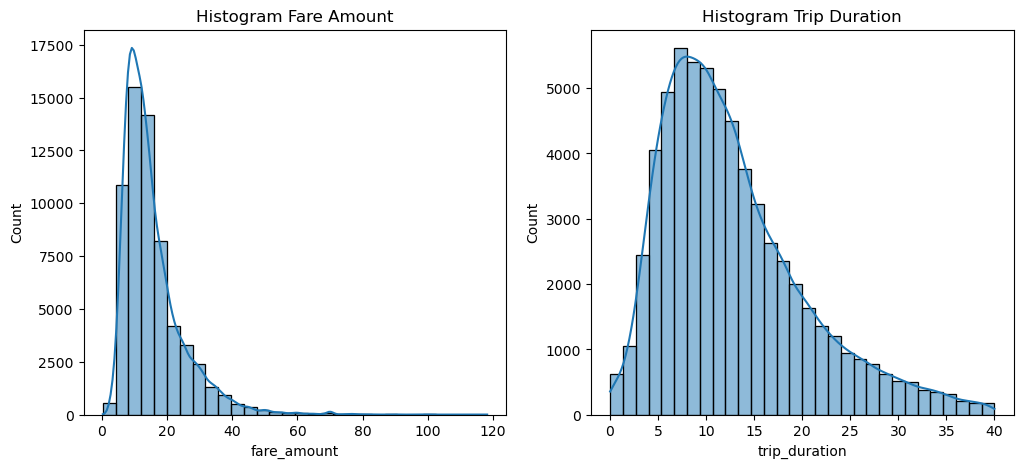

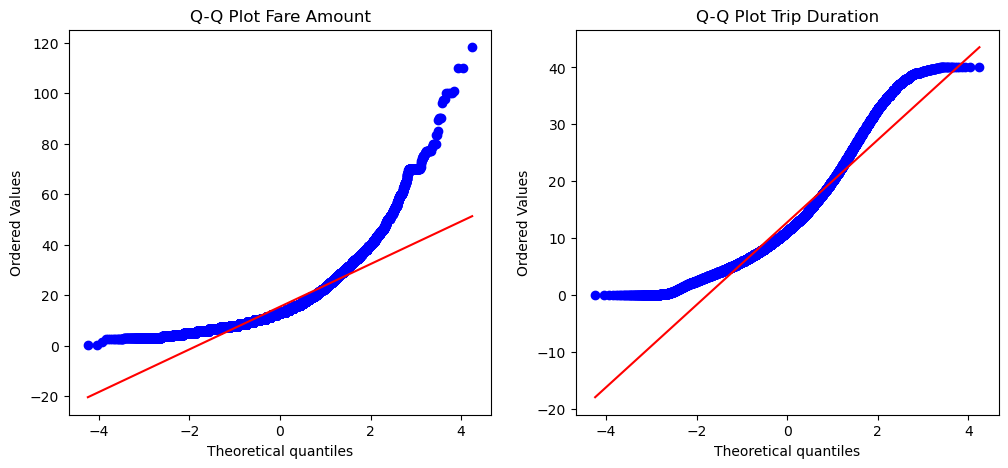

In [345]:
 # Uji normalitas menggunakan Shapiro-Wilk  
shapiro_fare = stats.shapiro(df_below_40_mnt['fare_amount'])  
shapiro_duration = stats.shapiro(df_below_40_mnt['trip_duration'])  
  
print(f'Uji Shapiro-Wilk untuk Fare Amount: Statistik = {shapiro_fare.statistic}, p-value = {shapiro_fare.pvalue}')  
print(f'Uji Shapiro-Wilk untuk Trip Duration: Statistik = {shapiro_duration.statistic}, p-value = {shapiro_duration.pvalue}')  
  
# Visualisasi Histogram  
plt.figure(figsize=(12, 5))  
  
plt.subplot(1, 2, 1)  
sns.histplot(df_below_40_mnt['fare_amount'], bins=30, kde=True)  
plt.title('Histogram Fare Amount')  
  
plt.subplot(1, 2, 2)  
sns.histplot(df_below_40_mnt['trip_duration'], bins=30, kde=True)  
plt.title('Histogram Trip Duration')  
  
plt.show()  
  
# Q-Q Plot  
plt.figure(figsize=(12, 5))  
  
plt.subplot(1, 2, 1)  
stats.probplot(df_below_40_mnt['fare_amount'], dist="norm", plot=plt)  
plt.title('Q-Q Plot Fare Amount')  
  
plt.subplot(1, 2, 2)  
stats.probplot(df_below_40_mnt['trip_duration'], dist="norm", plot=plt)  
plt.title('Q-Q Plot Trip Duration')  
  
plt.show()  


Karena p-value sangat kecil (jauh di bawah 0.05), kita menolak hipotesis nol yang menyatakan bahwa data Fare Amount terdistribusi normal. Ini menunjukkan bahwa distribusi Fare Amount tidak normal.

Sama seperti Fare Amount, p-value yang sangat kecil menunjukkan bahwa kita juga menolak hipotesis nol untuk Trip Duration. Ini berarti bahwa distribusi Trip Duration juga tidak normal.

In [340]:
spearman_correlation = df_below_40_mnt['fare_amount'].corr(df_below_40_mnt['trip_duration'], method='spearman')  
  
# Display the Spearman correlation value  
print(f'Korelasi Spearman antara Fare Amount dan Trip Duration: {spearman_correlation}')

Korelasi Spearman antara Fare Amount dan Trip Duration: 0.9175457249513594


* Kekuatan Korelasi: Nilai korelasi Spearman 0.9175 menunjukkan adanya hubungan yang sangat kuat dan positif antara jumlah tarif (Fare Amount) dan durasi perjalanan (Trip Duration). Ini berarti bahwa ketika durasi perjalanan meningkat, tarif yang dikenakan juga cenderung meningkat.

* Karakteristik Data: Korelasi Spearman mengukur hubungan monotonic antara dua variabel, yang berarti bahwa hubungan ini tidak harus linier, tetapi menunjukkan bahwa kedua variabel bergerak dalam arah yang sama.

## Problem Statement 1 = Hubungan Kategori Waktu Pick Up dengan Trip Duration

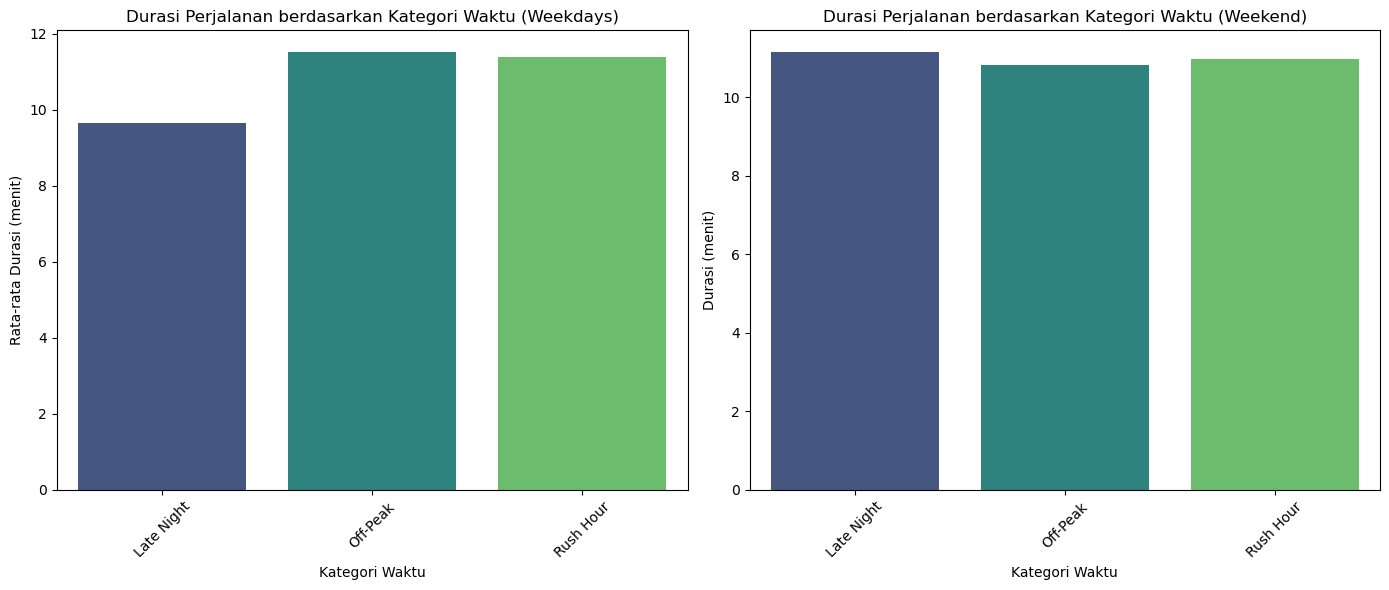

In [389]:
df_below_40_mnt = pd.DataFrame(df_below_40_mnt)  
  
# Mengubah kolom lpep_pickup_datetime dan lpep_dropoff_datetime menjadi datetime  
df_below_40_mnt['lpep_pickup_datetime'] = pd.to_datetime(df_below_40_mnt['lpep_pickup_datetime'])  
df_below_40_mnt['lpep_dropoff_datetime'] = pd.to_datetime(df_below_40_mnt['lpep_dropoff_datetime'])  
  
  
# Menambahkan kolom hari dan kategori waktu  
df_below_40_mnt['day_of_week'] = df_below_40_mnt['lpep_pickup_datetime'].dt.day_name()  
  
# Memisahkan data menjadi weekdays dan weekend  
df_below_40_mnt['is_weekend'] = df_below_40_mnt['day_of_week'].isin(['Saturday', 'Sunday'])  
weekdays_data = df_below_40_mnt[~df_below_40_mnt['is_weekend']]  
weekend_data = df_below_40_mnt[df_below_40_mnt['is_weekend']]  
  
# Menghitung rata-rata durasi perjalanan berdasarkan kategori waktu untuk weekdays  
weekdays_med_duration = weekdays_data.groupby('time_category')['trip_duration'].median().reset_index()  
  
# Menghitung rata-rata durasi perjalanan berdasarkan kategori waktu untuk weekend  
weekend_med_duration = weekend_data.groupby('time_category')['trip_duration'].median().reset_index()  
  
# Visualisasi  
plt.figure(figsize=(14, 6))  
  
# Bar plot untuk weekdays  
plt.subplot(1, 2, 1)  
sns.barplot(x='time_category', y='trip_duration', data=weekdays_med_duration, palette='viridis')  
plt.title('Durasi Perjalanan berdasarkan Kategori Waktu (Weekdays)')  
plt.xlabel('Kategori Waktu')  
plt.ylabel('Rata-rata Durasi (menit)')  
plt.xticks(rotation=45)  
  
# Bar plot untuk weekend  
plt.subplot(1, 2, 2)  
sns.barplot(x='time_category', y='trip_duration', data=weekend_med_duration, palette='viridis')  
plt.title('Durasi Perjalanan berdasarkan Kategori Waktu (Weekend)')  
plt.xlabel('Kategori Waktu')  
plt.ylabel('Durasi (menit)')  
plt.xticks(rotation=45)  
  
plt.tight_layout()  
plt.show()  

* Weekdays:
Dari grafik, terlihat bahwa durasi perjalanan pada kategori Late Night cenderung lebih tinggi dibandingkan dengan kategori Off-Peak dan Rush Hour.
Ini mungkin menunjukkan bahwa perjalanan larut malam lebih lama, mungkin karena faktor-faktor seperti lalu lintas yang lebih sedikit atau rute yang lebih panjang.

* Weekend:
Pada grafik weekend, pola yang sama mungkin terlihat, tetapi perbandingan antara kategori waktu dapat berbeda.
Misalnya, durasi perjalanan pada Rush Hour mungkin tidak seintensif pada weekdays, tergantung pada kebiasaan perjalanan orang di akhir pekan.

In [390]:
weekdays_duration = weekdays_data['trip_duration']  
weekend_duration = weekend_data['trip_duration']

# 1. Uji Normalitas  
shapiro_weekdays = stats.shapiro(weekdays_duration)  
shapiro_weekend = stats.shapiro(weekend_duration)  
  
print("Uji Normalitas (Weekdays):", shapiro_weekdays)  
print("Uji Normalitas (Weekend):", shapiro_weekend)  
  
data_to_test = [weekdays_duration, weekend_duration]  
  
# Uji Kruskal-Wallis  
kruskal_test = stats.kruskal(*data_to_test)  
  
# Menampilkan hasil  
print("Hasil Uji Kruskal-Wallis:")  
print("Statistik H:", kruskal_test.statistic)  
print("Nilai p:", kruskal_test.pvalue)  
  
# Interpretasi hasil  
alpha = 0.05  
if kruskal_test.pvalue < alpha:  
    print("Ada perbedaan signifikan dalam durasi perjalanan antara weekdays dan weekend.")  
else:  
    print("Tidak ada perbedaan signifikan dalam durasi perjalanan antara weekdays dan weekend.") 

Uji Normalitas (Weekdays): ShapiroResult(statistic=0.9293785846047313, pvalue=3.29153360305978e-87)
Uji Normalitas (Weekend): ShapiroResult(statistic=0.9280062936265063, pvalue=8.743806559410698e-65)
Hasil Uji Kruskal-Wallis:
Statistik H: 44.043164060735435
Nilai p: 3.212137171352732e-11
Ada perbedaan signifikan dalam durasi perjalanan antara weekdays dan weekend.


* Uji Normalitas untuk Weekdays:
Statistik: 0.9294
p-value: 3.2915e-87
Interpretasi: P-value yang sangat kecil menunjukkan bahwa data durasi perjalanan pada weekdays tidak terdistribusi normal.

* Uji Normalitas untuk Weekend:
Statistik: 0.9280
p-value: 8.7438e-65
Interpretasi: P-value yang juga sangat kecil menunjukkan bahwa data durasi perjalanan pada weekend juga tidak terdistribusi normal.

* Hasil Uji Kruskal-Wallis:
Statistik H: 44.0432
p-value: 3.2121e-11
Interpretasi: P-value yang sangat kecil menunjukkan bahwa ada perbedaan signifikan dalam durasi perjalanan antara weekdays dan weekend. Ini berarti bahwa durasi perjalanan pada weekdays dan weekend tidak sama.

In [391]:
# Menambahkan kolom is_weekend  
df_below_40_mnt['is_weekend'] = df_below_40_mnt['day_of_week'].isin(['Saturday', 'Sunday'])  
  
# Mengelompokkan data berdasarkan time_category, is_weekend, dan pickup_location_id   
grouped = df_below_40_mnt.groupby(['time_category', 'is_weekend', 'PUZone'])['trip_duration'].mean().reset_index()  
  
# Menemukan PUZone dengan trip_duration tertinggi untuk setiap kombinasi time_category dan is_weekend  
highest_trip_duration = grouped.loc[grouped.groupby(['time_category', 'is_weekend'])['trip_duration'].idxmax()]  
  
# Menampilkan hasil  
print("PUZone dengan trip_duration tertinggi berdasarkan time_category dan apakah itu weekend atau weekday:")  
print(highest_trip_duration)  


PUZone dengan trip_duration tertinggi berdasarkan time_category dan apakah itu weekend atau weekday:
    time_category  is_weekend                   PUZone  trip_duration
83     Late Night       False               Ozone Park      35.200000
133    Late Night        True           Brighton Beach      35.000000
296      Off-Peak       False            Fresh Meadows      37.266667
435      Off-Peak        True            Cypress Hills      37.350000
543     Rush Hour       False  Bloomfield/Emerson Hill      36.550000
695     Rush Hour        True                  Bayside      39.300000


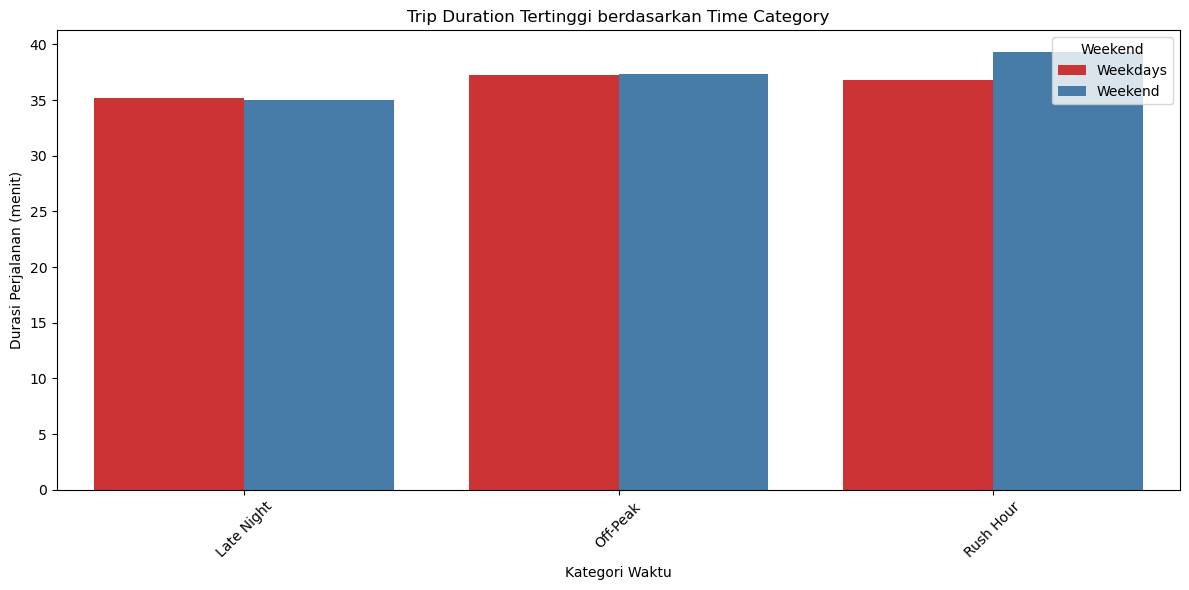

In [392]:
grouped = df_below_40_mnt.groupby(['time_category', 'is_weekend', 'PUZone'])['trip_duration'].median().reset_index()  
  
# Menemukan PUZone dengan trip_duration tertinggi untuk setiap kombinasi time_category dan is_weekend  
highest_trip_duration = grouped.loc[grouped.groupby(['time_category', 'is_weekend'])['trip_duration'].idxmax()]  
  
# Membuat bar plot  
plt.figure(figsize=(12, 6))  
sns.barplot(data=highest_trip_duration,   
            x='time_category',   
            y='trip_duration',   
            hue='is_weekend',   
            palette='Set1',   
            ci=None)  
  
# Menambahkan label dan judul  
plt.title('Trip Duration Tertinggi berdasarkan Time Category')  
plt.xlabel('Kategori Waktu')  
plt.ylabel('Durasi Perjalanan (menit)')  
plt.xticks(rotation=45)  
plt.legend(title='Weekend', labels=['Weekdays', 'Weekend'])  
  
plt.tight_layout()  
plt.show()  

* Late Night:
Dari grafik, terlihat bahwa durasi perjalanan pada kategori Late Night untuk weekdays (merah) lebih tinggi dibandingkan dengan weekend (biru). Ini menunjukkan bahwa perjalanan larut malam pada weekdays cenderung lebih lama.

* Off-Peak:
Pada kategori Off-Peak, durasi perjalanan untuk weekdays juga lebih tinggi dibandingkan dengan weekend, meskipun perbedaannya mungkin tidak sebesar pada kategori Late Night.

* Rush Hour:
Pada kategori Rush Hour, perbedaan antara weekdays dan weekend mungkin lebih kecil, tetapi weekdays tetap menunjukkan durasi yang lebih tinggi. Ini menunjukkan bahwa perjalanan pada jam sibuk di weekdays lebih lama dibandingkan dengan weekend.

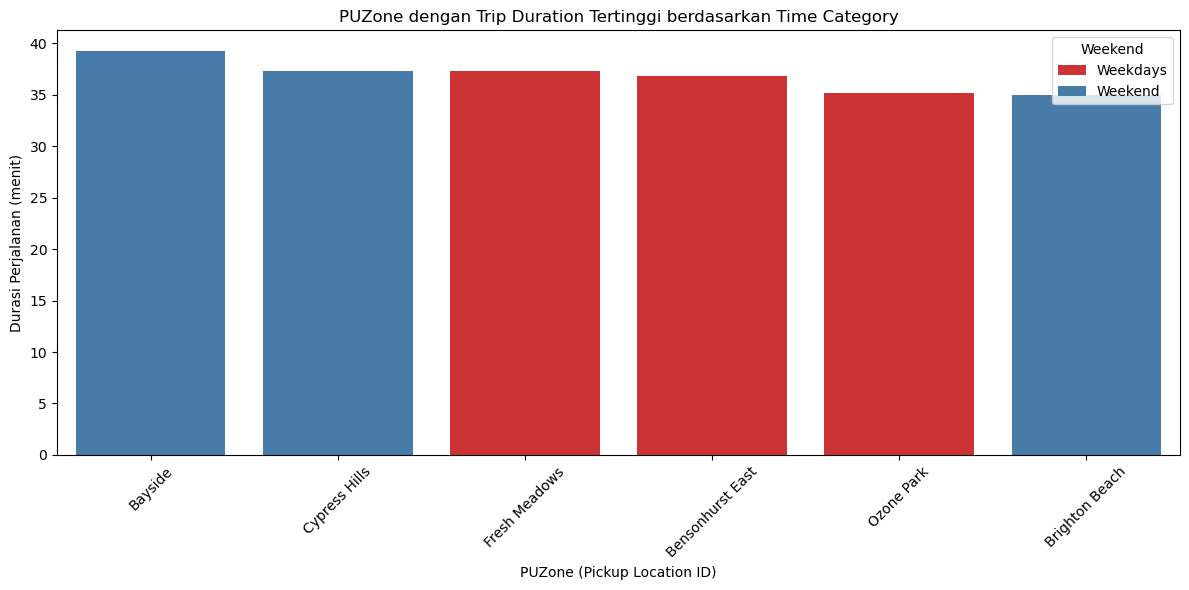

In [393]:
# Menemukan PUZone dengan trip_duration tertinggi untuk setiap kombinasi time_category dan is_weekend  
highest_trip_duration = highest_trip_duration.sort_values(by='trip_duration', ascending=False)
  
# Membuat bar plot  
plt.figure(figsize=(12, 6))  
sns.barplot(data=highest_trip_duration,   
            x='PUZone',   
            y='trip_duration',   
            hue='is_weekend',   
            palette='Set1',   
            ci=None)  
  
# Menambahkan label dan judul  
plt.title('PUZone dengan Trip Duration Tertinggi berdasarkan Time Category')  
plt.xlabel('PUZone (Pickup Location ID)')  
plt.ylabel('Durasi Perjalanan (menit)')  
plt.xticks(rotation=45)  
plt.legend(title='Weekend', labels=['Weekdays', 'Weekend'])  
  
plt.tight_layout()  
plt.show()  

* Perbandingan Durasi:
Dari grafik, kita dapat melihat perbandingan rata-rata durasi perjalanan untuk setiap zona penjemputan antara weekdays dan weekend.
Warna merah menunjukkan durasi perjalanan pada weekdays, sedangkan warna biru menunjukkan durasi perjalanan pada weekend.

* Pola Umum:
Jika bar merah (weekdays) lebih tinggi daripada bar biru (weekend) untuk zona tertentu, ini menunjukkan bahwa durasi perjalanan pada weekdays lebih lama dibandingkan dengan weekend di zona tersebut, dan sebaliknya.
Misalnya, jika zona Bayside menunjukkan bar merah yang lebih tinggi, ini berarti perjalanan dari Bayside pada weekdays lebih lama dibandingkan dengan weekend.

 ## Hubungan Kategori Waktu Pick Up dengan Fare Amount

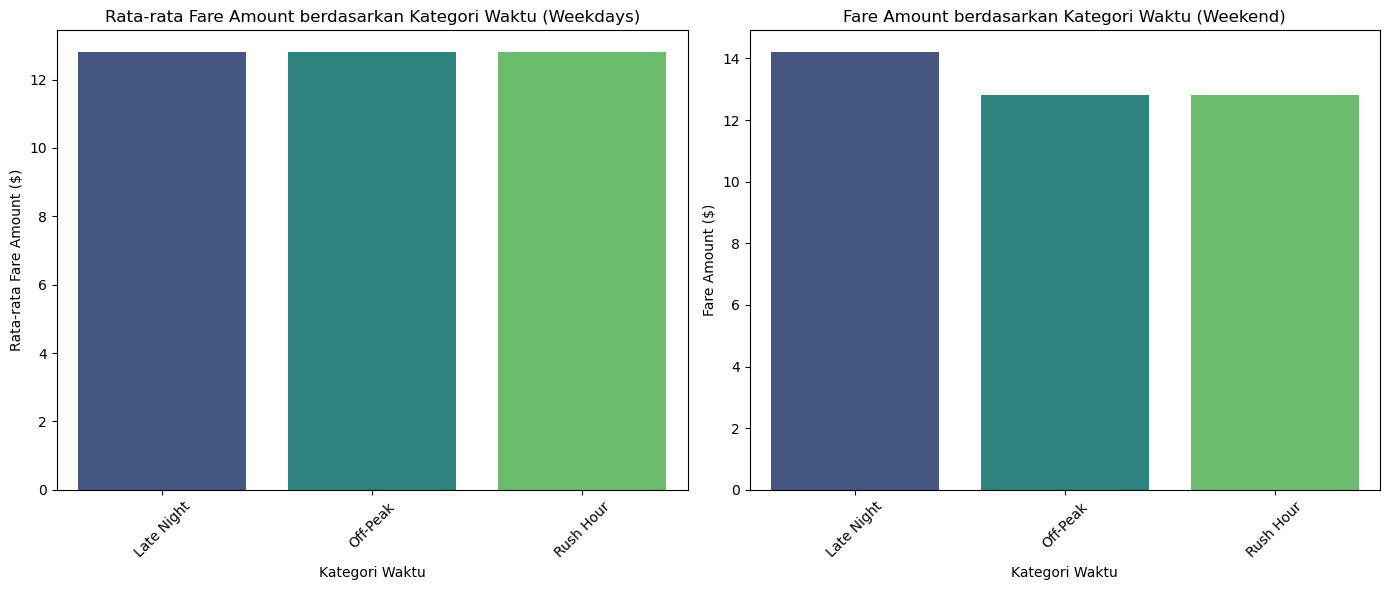

In [394]:
# Menghitung rata-rata durasi perjalanan berdasarkan kategori waktu untuk weekdays  
weekdays_med_duration = weekdays_data.groupby('time_category')['fare_amount'].median().reset_index()  
  
# Menghitung rata-rata durasi perjalanan berdasarkan kategori waktu untuk weekend  
weekend_med_duration = weekend_data.groupby('time_category')['fare_amount'].median().reset_index()  
  
# Visualisasi  
plt.figure(figsize=(14, 6))  
  
# Bar plot untuk weekdays  
plt.subplot(1, 2, 1)  
sns.barplot(x='time_category', y='fare_amount', data=weekdays_med_duration, palette='viridis')  
plt.title('Rata-rata Fare Amount berdasarkan Kategori Waktu (Weekdays)')  
plt.xlabel('Kategori Waktu')  
plt.ylabel('Rata-rata Fare Amount ($)')  
plt.xticks(rotation=45)  
  
# Bar plot untuk weekend  
plt.subplot(1, 2, 2)  
sns.barplot(x='time_category', y='fare_amount', data=weekend_med_duration, palette='viridis')  
plt.title('Fare Amount berdasarkan Kategori Waktu (Weekend)')  
plt.xlabel('Kategori Waktu')  
plt.ylabel('Fare Amount ($)')  
plt.xticks(rotation=45)  
  
plt.tight_layout()  
plt.show()  

* Weekdays:
Dari grafik sebelah kiri, terlihat bahwa fare amount pada kategori Late Night cenderung lebih tinggi dibandingkan dengan kategori Off-Peak dan Rush Hour. Ini menunjukkan bahwa tarif untuk perjalanan larut malam lebih mahal, mungkin karena faktor permintaan yang lebih tinggi atau jarak yang lebih jauh.

* Weekend:
Pada grafik sebelah kanan, pola fare amount untuk weekend juga menunjukkan bahwa kategori Late Night memiliki tarif yang lebih tinggi dibandingkan dengan kategori Off-Peak dan Rush Hour. Namun, perbandingan antara weekdays dan weekend dapat memberikan wawasan lebih lanjut tentang bagaimana tarif bervariasi antara hari kerja dan akhir pekan.

In [395]:
weekdays_fare_amount = weekdays_data['fare_amount']  
weekend_fare_amount = weekend_data['fare_amount']

# 1. Uji Normalitas  
shapiro_weekdays_fare = stats.shapiro(weekdays_fare_amount)  
shapiro_weekend_fare = stats.shapiro(weekend_fare_amount)  
  
print("Uji Normalitas (Weekdays):", shapiro_weekdays_fare)  
print("Uji Normalitas (Weekend):", shapiro_weekend_fare)  
  
data_to_test_fare_amount = [weekdays_fare_amount, weekend_fare_amount]  
  
# Uji Kruskal-Wallis  
kruskal_test = stats.kruskal(*data_to_test_fare_amount)  
  
# Menampilkan hasil  
print("Hasil Uji Kruskal-Wallis:")  
print("Statistik H:", kruskal_test.statistic)  
print("Nilai p:", kruskal_test.pvalue)  
  
# Interpretasi hasil  
alpha = 0.05  
if kruskal_test.pvalue < alpha:  
    print("Ada perbedaan signifikan dalam fare amount antara weekdays dan weekend.")  
else:  
    print("Tidak ada perbedaan signifikan dalam fare amount antara weekdays dan weekend.") 

Uji Normalitas (Weekdays): ShapiroResult(statistic=0.8451123184694931, pvalue=5.88303998459686e-107)
Uji Normalitas (Weekend): ShapiroResult(statistic=0.813325180974562, pvalue=2.739833741824387e-85)
Hasil Uji Kruskal-Wallis:
Statistik H: 19.00745210917779
Nilai p: 1.3020893101915936e-05
Ada perbedaan signifikan dalam fare amount antara weekdays dan weekend.


In [396]:
# Menambahkan kolom is_weekend  
df_below_40_mnt['is_weekend'] = df_below_40_mnt['day_of_week'].isin(['Saturday', 'Sunday'])  
  
# Mengelompokkan data berdasarkan time_category, is_weekend, dan pickup_location_id  
grouped = df_below_40_mnt.groupby(['time_category', 'is_weekend', 'PUZone'])['fare_amount'].mean().reset_index()  
  
# Menemukan PUZone dengan fare_amount tertinggi untuk setiap kombinasi time_category dan is_weekend  
highest_fare_amount = grouped.loc[grouped.groupby(['time_category', 'is_weekend'])['fare_amount'].idxmax()]  
  
# Menampilkan hasil  
print("PUZone dengan fare amount tertinggi berdasarkan time_category dan apakah itu weekend atau weekday:")  
print(highest_fare_amount)  


PUZone dengan fare amount tertinggi berdasarkan time_category dan apakah itu weekend atau weekday:
    time_category  is_weekend                         PUZone  fare_amount
106    Late Night       False  Sutton Place/Turtle Bay North        77.00
171    Late Night        True                      Glen Oaks        75.00
252      Off-Peak       False                Cambria Heights        62.85
509      Off-Peak        True                  South Jamaica        64.60
540     Rush Hour       False                      Bellerose        60.00
709     Rush Hour        True                Cambria Heights        64.60


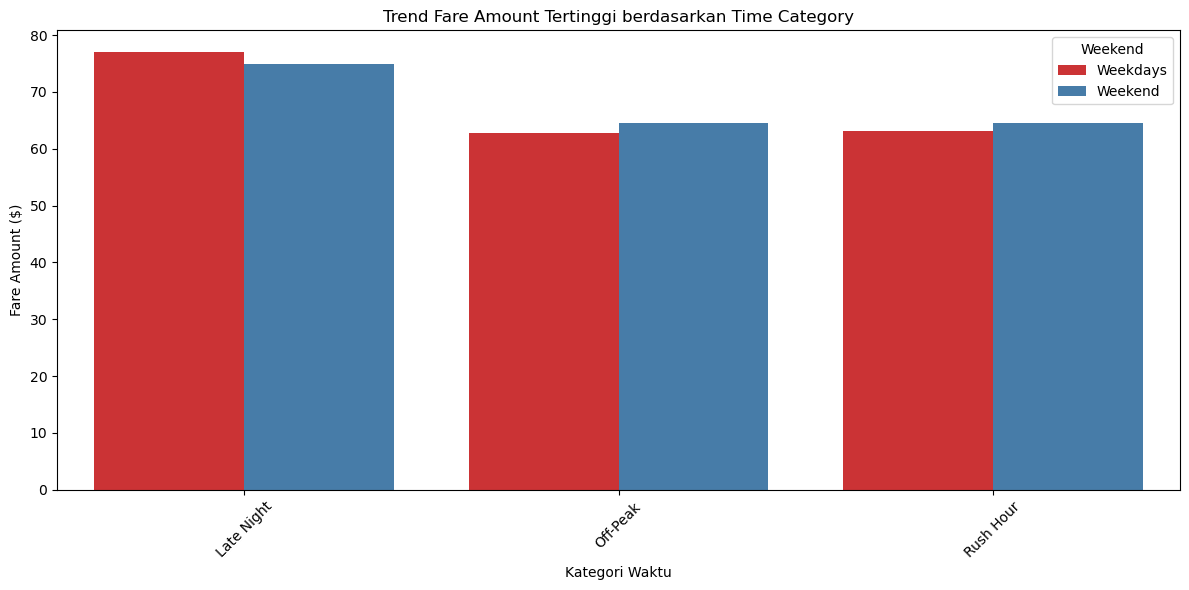

In [397]:
grouped = df_below_40_mnt.groupby(['time_category', 'is_weekend', 'PUZone'])['fare_amount'].median().reset_index()  
  
# Menemukan PUZone dengan fare_amount tertinggi untuk setiap kombinasi time_category dan is_weekend  
highest_trip_duration = grouped.loc[grouped.groupby(['time_category', 'is_weekend'])['fare_amount'].idxmax()]  
  
# Membuat bar plot  
plt.figure(figsize=(12, 6))  
sns.barplot(data=highest_trip_duration,   
            x='time_category',   
            y='fare_amount',   
            hue='is_weekend',   
            palette='Set1',   
            ci=None)  
  
# Menambahkan label dan judul  
plt.title('Trend Fare Amount Tertinggi berdasarkan Time Category')  
plt.xlabel('Kategori Waktu')  
plt.ylabel('Fare Amount ($)')  
plt.xticks(rotation=45)  
plt.legend(title='Weekend', labels=['Weekdays', 'Weekend'])  
  
plt.tight_layout()  
plt.show()  

* Late Night:
Dari grafik, terlihat bahwa fare amount pada kategori Late Night untuk weekdays (merah) jauh lebih tinggi dibandingkan dengan weekend (biru). Ini menunjukkan bahwa tarif untuk perjalanan larut malam pada weekdays lebih mahal, mungkin karena permintaan yang lebih tinggi atau faktor lain seperti jarak yang lebih jauh.
* Off-Peak:
Pada kategori Off-Peak, fare amount untuk weekdays juga lebih tinggi dibandingkan dengan weekend, meskipun perbedaannya mungkin tidak sebesar pada kategori Late Night.
* Rush Hour:
Pada kategori Rush Hour, fare amount untuk weekdays tetap lebih tinggi dibandingkan dengan weekend. Ini menunjukkan bahwa perjalanan pada jam sibuk di weekdays lebih mahal, yang mungkin disebabkan oleh tingginya permintaan pada waktu tersebut.

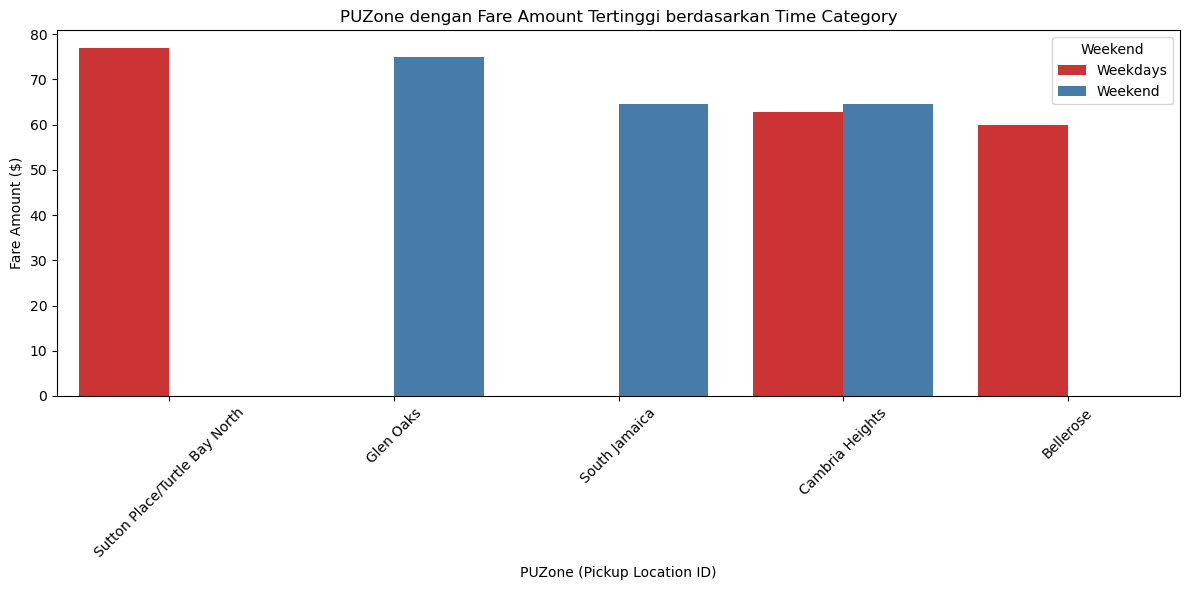

In [398]:
# Menemukan PUZone dengan trip_duration tertinggi untuk setiap kombinasi time_category dan is_weekend  
highest_fare_amount = highest_fare_amount.sort_values(by='fare_amount', ascending=False)
  
# Membuat bar plot  
plt.figure(figsize=(12, 6))  
sns.barplot(data=highest_fare_amount,   
            x='PUZone',   
            y='fare_amount',   
            hue='is_weekend',   
            palette='Set1',   
            ci=None)  
  
# Menambahkan label dan judul  
plt.title('PUZone dengan Fare Amount Tertinggi berdasarkan Time Category')  
plt.xlabel('PUZone (Pickup Location ID)')  
plt.ylabel('Fare Amount ($)')  
plt.xticks(rotation=45)  
plt.legend(title='Weekend', labels=['Weekdays', 'Weekend'])  
  
plt.tight_layout()  
plt.show()  

## Hubungan Katagori Waktu Pick Up dengan Tip Amount

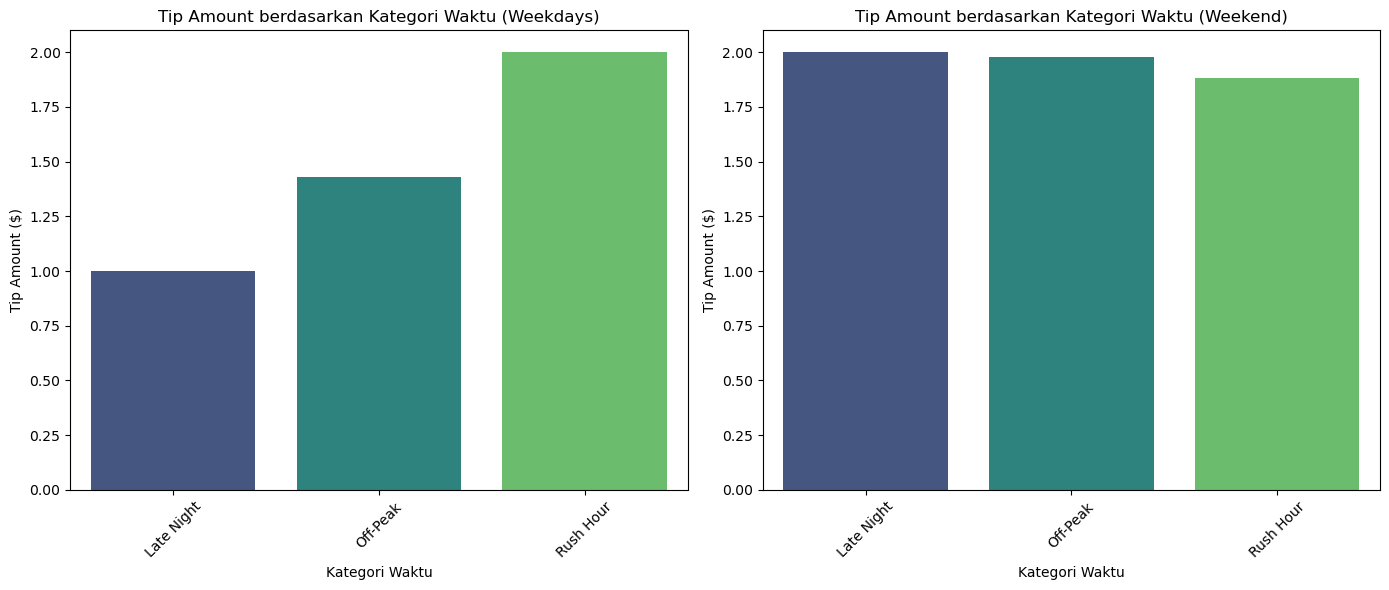

In [399]:
# Menghitung rata-rata durasi perjalanan berdasarkan kategori waktu untuk weekdays  
weekdays_med_tip = weekdays_data.groupby('time_category')['tip_amount'].median().reset_index()  
  
# Menghitung rata-rata durasi perjalanan berdasarkan kategori waktu untuk weekend  
weekend_med_tip = weekend_data.groupby('time_category')['tip_amount'].median().reset_index()  
  
# Visualisasi  
plt.figure(figsize=(14, 6))  
  
# Bar plot untuk weekdays  
plt.subplot(1, 2, 1)  
sns.barplot(x='time_category', y='tip_amount', data=weekdays_med_tip, palette='viridis')  
plt.title('Tip Amount berdasarkan Kategori Waktu (Weekdays)')  
plt.xlabel('Kategori Waktu')  
plt.ylabel('Tip Amount ($)')  
plt.xticks(rotation=45)  
  
# Bar plot untuk weekend  
plt.subplot(1, 2, 2)  
sns.barplot(x='time_category', y='tip_amount', data=weekend_med_tip, palette='viridis')  
plt.title('Tip Amount berdasarkan Kategori Waktu (Weekend)')  
plt.xlabel('Kategori Waktu')  
plt.ylabel('Tip Amount ($)')  
plt.xticks(rotation=45)  
  
plt.tight_layout()  
plt.show()  

* Weekdays:
Dari grafik sebelah kiri, terlihat bahwa rata-rata tip amount pada kategori Late Night cenderung lebih tinggi dibandingkan dengan kategori Off-Peak dan Rush Hour. Ini menunjukkan bahwa pelanggan cenderung memberikan tip yang lebih besar pada perjalanan larut malam.

* Weekend:
Pada grafik sebelah kanan, pola yang sama terlihat, di mana rata-rata tip amount pada kategori Late Night juga lebih tinggi dibandingkan dengan kategori Off-Peak dan Rush Hour. Namun, perbandingan antara weekdays dan weekend dapat memberikan wawasan lebih lanjut tentang bagaimana tip bervariasi antara hari kerja dan akhir pekan.

In [368]:
weekdays_tip_amount = weekdays_data['tip_amount']  
weekend_tip_amount = weekend_data['tip_amount']

# 1. Uji Normalitas  
shapiro_weekdays_tip = stats.shapiro(weekdays_tip_amount)  
shapiro_weekend_tip = stats.shapiro(weekend_tip_amount)  
  
print("Uji Normalitas (Weekdays):", shapiro_weekdays_tip)  
print("Uji Normalitas (Weekend):", shapiro_weekend_tip)  
  
data_to_test_tip_amount = [weekdays_tip_amount, weekend_tip_amount]  
  
# Uji Kruskal-Wallis  
kruskal_test = stats.kruskal(*data_to_test_tip_amount)  
  
# Menampilkan hasil  
print("Hasil Uji Kruskal-Wallis:")  
print("Statistik H:", kruskal_test.statistic)  
print("Nilai p:", kruskal_test.pvalue)  
  
# Interpretasi hasil  
alpha = 0.05  
if kruskal_test.pvalue < alpha:  
    print("Ada perbedaan signifikan dalam tip amount antara weekdays dan weekend.")  
else:  
    print("Tidak ada perbedaan signifikan dalam tip amount antara weekdays dan weekend.") 

Uji Normalitas (Weekdays): ShapiroResult(statistic=0.6566012624918076, pvalue=4.515345779700043e-129)
Uji Normalitas (Weekend): ShapiroResult(statistic=0.690970849535171, pvalue=2.656111162420671e-97)
Hasil Uji Kruskal-Wallis:
Statistik H: 8.310892650480604
Nilai p: 0.003940801859148974
Ada perbedaan signifikan dalam tip amount antara weekdays dan weekend.


In [370]:
# Menambahkan kolom is_weekend  
df_below_40_mnt['is_weekend'] = df_below_40_mnt['day_of_week'].isin(['Saturday', 'Sunday'])  
  
# Mengelompokkan data berdasarkan time_category, is_weekend, dan pickup_location_id  
grouped = df_below_40_mnt.groupby(['time_category', 'is_weekend', 'PUZone'])['tip_amount'].mean().reset_index()  
  
# Menemukan PUZone dengan fare_amount tertinggi untuk setiap kombinasi time_category dan is_weekend  
highest_tip_amount = grouped.loc[grouped.groupby(['time_category', 'is_weekend'])['tip_amount'].idxmax()]  
  
# Menampilkan hasil  
print("PUZone dengan tip amount tertinggi berdasarkan time_category dan apakah itu weekend atau weekday:")  
print(highest_tip_amount)  

PUZone dengan tip amount tertinggi berdasarkan time_category dan apakah itu weekend atau weekday:
    time_category  is_weekend                        PUZone  tip_amount
81     Late Night       False           Ocean Parkway South     36.8000
133    Late Night        True                Brighton Beach     13.7700
292      Off-Peak       False  Flushing Meadows-Corona Park     19.9000
509      Off-Peak        True                 South Jamaica     14.5300
674     Rush Hour       False              Sunset Park East     14.1785
706     Rush Hour        True                   Brownsville     22.8000


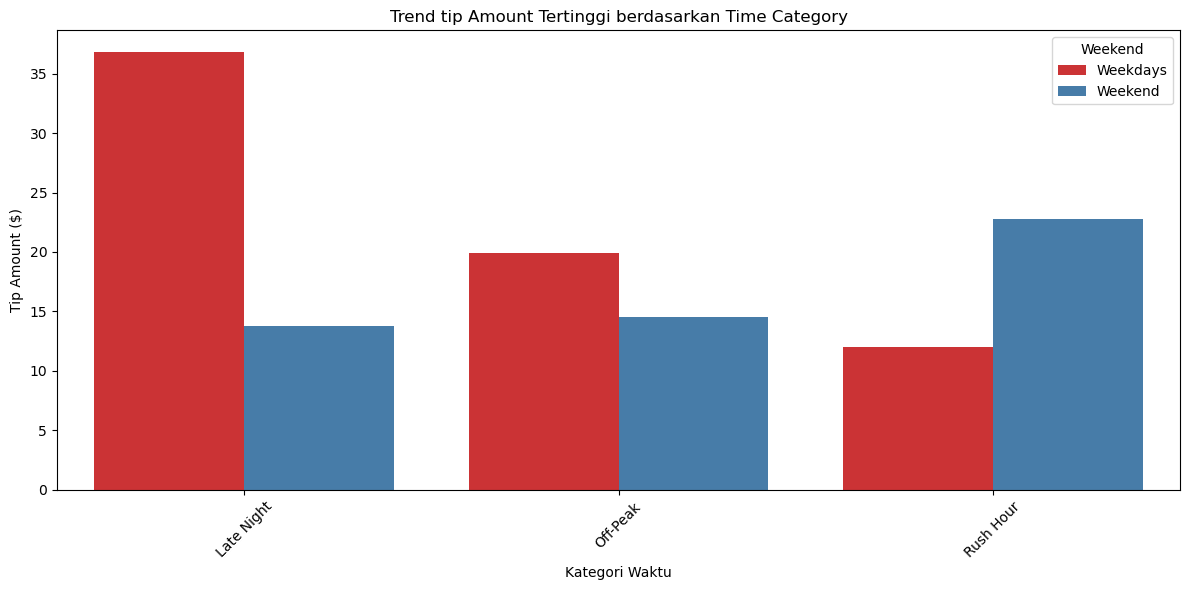

In [400]:
grouped = df_below_40_mnt.groupby(['time_category', 'is_weekend', 'PUZone'])['tip_amount'].median().reset_index()  
  
# Menemukan PUZone dengan fare_amount tertinggi untuk setiap kombinasi time_category dan is_weekend  
highest_tip_amount = grouped.loc[grouped.groupby(['time_category', 'is_weekend'])['tip_amount'].idxmax()]  
  
# Membuat bar plot  
plt.figure(figsize=(12, 6))  
sns.barplot(data=highest_tip_amount,   
            x='time_category',   
            y='tip_amount',   
            hue='is_weekend',   
            palette='Set1',   
            ci=None)  
  
# Menambahkan label dan judul  
plt.title('Trend tip Amount Tertinggi berdasarkan Time Category')  
plt.xlabel('Kategori Waktu')  
plt.ylabel('Tip Amount ($)')  
plt.xticks(rotation=45)  
plt.legend(title='Weekend', labels=['Weekdays', 'Weekend'])  
  
plt.tight_layout()  
plt.show()  

* Late Night:
Dari grafik, terlihat bahwa rata-rata tip amount pada kategori Late Night untuk weekdays (merah) jauh lebih tinggi dibandingkan dengan weekend (biru). Ini menunjukkan bahwa pelanggan cenderung memberikan tip yang lebih besar pada perjalanan larut malam di hari kerja.

* Off-Peak:
Pada kategori Off-Peak, tip amount untuk weekdays juga lebih tinggi dibandingkan dengan weekend, meskipun perbedaannya mungkin tidak sebesar pada kategori Late Night.

* Rush Hour:
Pada kategori Rush Hour, tip amount untuk weekend (biru) lebih tinggi dibandingkan dengan weekdays (merah). Ini menunjukkan bahwa pelanggan cenderung memberikan tip yang lebih besar pada perjalanan di jam sibuk pada akhir pekan.

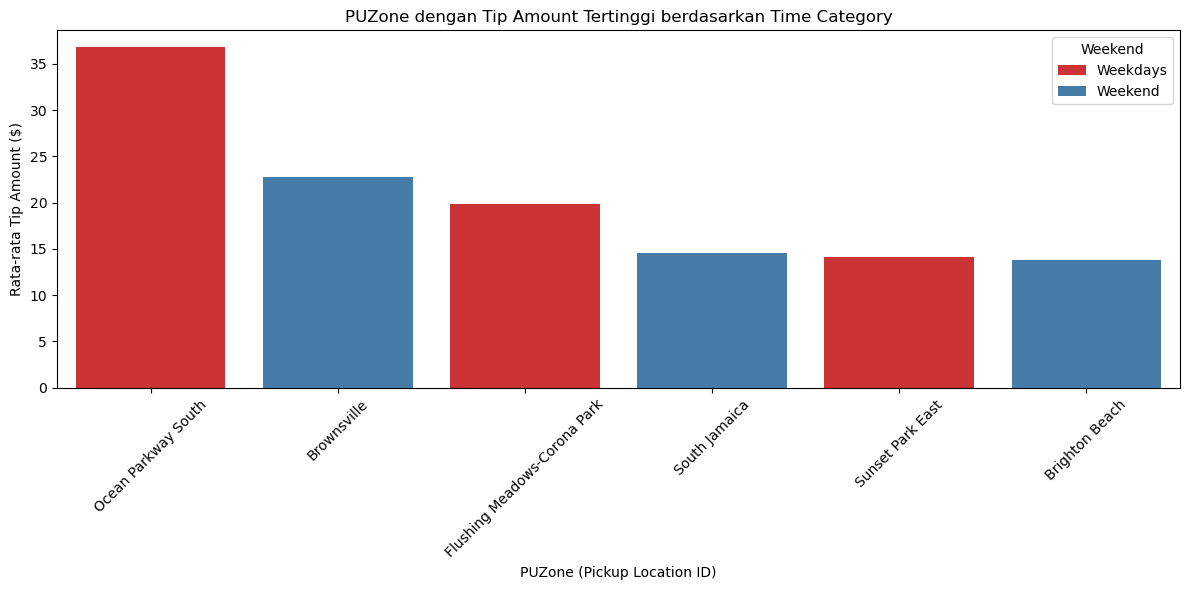

In [373]:
# Menemukan PUZone dengan tip_amount tertinggi untuk setiap kombinasi time_category dan is_weekend  
highest_tip_amount = highest_tip_amount.sort_values(by='tip_amount', ascending=False)
  
# Membuat bar plot  
plt.figure(figsize=(12, 6))  
sns.barplot(data=highest_tip_amount,   
            x='PUZone',   
            y='tip_amount',   
            hue='is_weekend',   
            palette='Set1',   
            ci=None)  
  
# Menambahkan label dan judul  
plt.title('PUZone dengan Tip Amount Tertinggi berdasarkan Time Category')  
plt.xlabel('PUZone (Pickup Location ID)')  
plt.ylabel('Rata-rata Tip Amount ($)')  
plt.xticks(rotation=45)  
plt.legend(title='Weekend', labels=['Weekdays', 'Weekend'])  
  
plt.tight_layout()  
plt.show()  

* Variasi Tip: Grafik ini menunjukkan bahwa tip amount bervariasi tergantung pada zona penjemputan dan hari. Secara umum, tarif untuk perjalanan dari Ocean Parkway South dan beberapa zona lainnya lebih tinggi pada weekdays, sementara beberapa zona menunjukkan tarif yang lebih tinggi pada weekend.
* Implikasi untuk Penetapan Harga: Informasi ini dapat digunakan untuk merumuskan strategi penetapan harga yang lebih efektif, dengan mempertimbangkan lokasi penjemputan dan waktu perjalanan dalam menentukan tarif.

## BAB 3 

* PENUTUP

## KESIMPULAN 

Insight
* Durasi Perjalanan:
Durasi perjalanan bervariasi tergantung pada waktu dan hari. Umumnya, perjalanan larut malam cenderung lebih lama pada weekdays, sedangkan durasi pada weekend menunjukkan pola yang berbeda, dengan beberapa zona memiliki durasi yang lebih pendek.

* Fare Amount:
Fare amount tertinggi terlihat pada kategori Late Night dan Rush Hour untuk weekdays, menunjukkan bahwa tarif lebih tinggi pada waktu-waktu tertentu. Pada weekend, fare amount juga menunjukkan tren serupa, tetapi dengan perbedaan yang lebih kecil antara kategori waktu.

* Tip Amount:
Rata-rata tip amount cenderung lebih tinggi pada kategori Late Night untuk weekdays, menunjukkan bahwa pelanggan lebih dermawan pada waktu tersebut. Sebaliknya, pada jam sibuk di weekend, tip amount lebih tinggi, menunjukkan bahwa pelanggan mungkin lebih menghargai layanan pada waktu-waktu sibuk.

* Perbandingan Zona Penjemputan:
Zona penjemputan seperti Ocean Parkway South menunjukkan tip amount yang lebih tinggi pada weekdays, sementara zona lain seperti Brownsville menunjukkan tip yang lebih tinggi pada weekend. Ini menunjukkan bahwa perilaku pelanggan bervariasi berdasarkan lokasi.

## Rekomendasi

* Variasi Berdasarkan Waktu dan Hari: Data menunjukkan bahwa durasi perjalanan, fare amount, dan tip amount bervariasi secara signifikan tergantung pada waktu (late night, off-peak, rush hour) dan hari (weekdays vs. weekend). Ini menunjukkan pentingnya mempertimbangkan waktu dan hari dalam perencanaan operasional dan strategi penetapan harga. Terutama bisa dilihat bahwa durasi perjalanan terpanjang terjadi pada weekends dimana pick up dilakukan pada distrik Bayside dan Cypress Hill. Dari sini dapat direkomendasikan untuk mencari rute lain untuk memotong waktu perjalanan.

* Strategi Penetapan Harga dan Layanan: Informasi ini dapat digunakan untuk merumuskan strategi penetapan harga yang lebih efektif, dengan mempertimbangkan waktu perjalanan dan zona penjemputan. Misalnya, tarif dapat disesuaikan untuk waktu-waktu tertentu untuk memaksimalkan pendapatan. Pada weekdend late night terdapat lonjakan penumpang yang memiliki tarif lebih tinggi dibanding waktu-waktu lainnya, dari sini pihay NYC Taxi dapat menyediakan armada tambahan untuk mengoptimalkan layanan.

* Peningkatan Pengalaman Pelanggan: Dengan memahami pola tip dan fare amount, perusahaan dapat meningkatkan pengalaman pelanggan, seperti memberikan insentif kepada pengemudi untuk meningkatkan layanan pada waktu-waktu tertentu, terutama saat permintaan tinggi.